#  Imports

In [37]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import warnings
from pathlib import Path


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

PRIMARY     = Path('../data/03_primary')
OUTPUT      = Path('../data/04_model_output')
OUTPUT.mkdir(parents=True, exist_ok=True)

# Cargar datos
df_rank   = pd.read_parquet(PRIMARY / 'municipio_features_rank.parquet')
df_master = pd.read_parquet(PRIMARY / 'municipio_features.parquet')

print(f'✅ Tabla rank:   {len(df_rank):,} municipios × {len(df_rank.columns)} columnas')
print(f'✅ Tabla master: {len(df_master):,} municipios × {len(df_master.columns)} columnas')

✅ Tabla rank:   1,122 municipios × 28 columnas
✅ Tabla master: 1,122 municipios × 48 columnas


# PARTE A — AHP (Analytic Hierarchy Process)
## Construcción del Índice de Riesgo Alimentario Municipal

In [2]:
# Dimensiones: D1=Producción, D2=Acceso, D3=Clima, D4=Socioeconómico
dimensiones = ['D1_Producción', 'D2_Acceso', 'D3_Clima', 'D4_Socioeconómico']
# Pesos objetivo
pesos_objetivo = np.array([0.35, 0.30, 0.15, 0.20])

# Calcular matriz exacta
n = len(pesos_objetivo)
matriz_exacta = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        matriz_exacta[i, j] = pesos_objetivo[i] / pesos_objetivo[j]

df_exacta = pd.DataFrame(
    matriz_exacta,
    index=dimensiones,
    columns=dimensiones
)

print('Matriz exacta para pesos 35/30/15/20:')
print(df_exacta.round(3).to_string())

print('\nVerificación — pesos resultantes:')
col_sums = matriz_exacta.sum(axis=0)
matriz_norm = matriz_exacta / col_sums
pesos_result = matriz_norm.mean(axis=1)
for dim, peso in zip(dimensiones, pesos_result):
    print(f'  {dim}: {peso:.4f} ({peso*100:.1f}%)')

print('\nVerificación CR (debe ser 0 para matriz perfecta):')
lambda_max = np.dot(matriz_exacta, pesos_result) / pesos_result
CI = (lambda_max.mean() - n) / (n - 1)
CR = CI / 0.90
print(f'  CR = {CR:.6f} (matriz perfectamente consistente = 0)')

Matriz exacta para pesos 35/30/15/20:
                   D1_Producción  D2_Acceso  D3_Clima  D4_Socioeconómico
D1_Producción             1.0000     1.1670    2.3330             1.7500
D2_Acceso                 0.8570     1.0000    2.0000             1.5000
D3_Clima                  0.4290     0.5000    1.0000             0.7500
D4_Socioeconómico         0.5710     0.6670    1.3330             1.0000

Verificación — pesos resultantes:
  D1_Producción: 0.3500 (35.0%)
  D2_Acceso: 0.3000 (30.0%)
  D3_Clima: 0.1500 (15.0%)
  D4_Socioeconómico: 0.2000 (20.0%)

Verificación CR (debe ser 0 para matriz perfecta):
  CR = 0.000000 (matriz perfectamente consistente = 0)


In [3]:
print('PASO 1 — Matriz de Comparación Pareada (Saaty)')
print('='*60)

# Escala de Saaty:
# 1 = igual importancia
# 3 = moderadamente más importante
# 5 = fuertemente más importante
# 7 = muy fuertemente más importante
# 9 = extremadamente más importante

# Justificación de juicios:
# D1 vs D2 = 1.167 — Producción ligeramente más importante que Acceso
# D1 vs D3 = 2.333 — Producción moderadamente más importante que Clima
# D1 vs D4 = 1.750 — Producción moderadamente más importante que Socioeconómico
# D2 vs D3 = 2.000 — Acceso dos veces más importante que Clima
# D2 vs D4 = 1.500 — Acceso más importante que Socioeconómico
# D3 vs D4 = 0.750 — Clima ligeramente menos importante que Socioeconómico

matriz_comparacion = np.array([
    [1.0000, 1.1670, 2.3330, 1.7500],  # D1 Producción
    [0.8570, 1.0000, 2.0000, 1.5000],  # D2 Acceso
    [0.4290, 0.5000, 1.0000, 0.7500],  # D3 Clima
    [0.5710, 0.6670, 1.3330, 1.0000],  # D4 Socioeconómico
])

df_matriz = pd.DataFrame(
    matriz_comparacion,
    index=dimensiones,
    columns=dimensiones
)

print('\nMatriz de comparación pareada:')
print(df_matriz.round(3).to_string())

# Verificar reciprocidad
print('\n✅ Verificación reciprocidad:')
for i in range(len(dimensiones)):
    for j in range(i+1, len(dimensiones)):
        reciproco = abs(matriz_comparacion[i,j] * matriz_comparacion[j,i] - 1) < 0.001
        print(f'  {dimensiones[i]} vs {dimensiones[j]}: {matriz_comparacion[i,j]:.3f} × {matriz_comparacion[j,i]:.3f} = {matriz_comparacion[i,j]*matriz_comparacion[j,i]:.3f} {"✅" if reciproco else "❌"}')

PASO 1 — Matriz de Comparación Pareada (Saaty)

Matriz de comparación pareada:
                   D1_Producción  D2_Acceso  D3_Clima  D4_Socioeconómico
D1_Producción             1.0000     1.1670    2.3330             1.7500
D2_Acceso                 0.8570     1.0000    2.0000             1.5000
D3_Clima                  0.4290     0.5000    1.0000             0.7500
D4_Socioeconómico         0.5710     0.6670    1.3330             1.0000

✅ Verificación reciprocidad:
  D1_Producción vs D2_Acceso: 1.167 × 0.857 = 1.000 ✅
  D1_Producción vs D3_Clima: 2.333 × 0.429 = 1.001 ✅
  D1_Producción vs D4_Socioeconómico: 1.750 × 0.571 = 0.999 ✅
  D2_Acceso vs D3_Clima: 2.000 × 0.500 = 1.000 ✅
  D2_Acceso vs D4_Socioeconómico: 1.500 × 0.667 = 1.001 ✅
  D3_Clima vs D4_Socioeconómico: 0.750 × 1.333 = 1.000 ✅


In [4]:
print('PASO 2 — Cálculo de Pesos (Vector de Prioridades)')
print('='*60)

# Método: normalización de la matriz
# 1. Sumar cada columna
col_sums = matriz_comparacion.sum(axis=0)
print(f'Suma por columna: {col_sums.round(3)}')

# 2. Dividir cada elemento por la suma de su columna
matriz_norm = matriz_comparacion / col_sums

# 3. Promedio de cada fila = peso de cada dimensión
pesos = matriz_norm.mean(axis=1)

print(f'\nPesos calculados:')
for dim, peso in zip(dimensiones, pesos):
    print(f'  {dim}: {peso:.4f} ({peso*100:.1f}%)')

print(f'\nVerificación suma pesos: {pesos.sum():.4f} (debe ser 1.0000)')

PASO 2 — Cálculo de Pesos (Vector de Prioridades)
Suma por columna: [2.857 3.334 6.666 5.   ]

Pesos calculados:
  D1_Producción: 0.3500 (35.0%)
  D2_Acceso: 0.3000 (30.0%)
  D3_Clima: 0.1500 (15.0%)
  D4_Socioeconómico: 0.2000 (20.0%)

Verificación suma pesos: 1.0000 (debe ser 1.0000)


In [5]:
print('PASO 3 — Verificación de Consistencia (CR)')
print('='*60)

n = len(dimensiones)

# Lambda máximo
lambda_max = np.dot(matriz_comparacion, pesos) / pesos
lambda_max_promedio = lambda_max.mean()
print(f'Lambda máximo (λmax): {lambda_max_promedio:.4f}')
print(f'Valores propios: {lambda_max.round(4)}')

# Índice de Consistencia
CI = (lambda_max_promedio - n) / (n - 1)
print(f'\nÍndice de Consistencia (CI): {CI:.4f}')

# Índice Aleatorio (Saaty)
RI = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90,
      5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41}
ri = RI[n]
print(f'Índice Aleatorio (RI) para n={n}: {ri}')

# Ratio de Consistencia
CR = CI / ri
print(f'\nRatio de Consistencia (CR): {CR:.4f}')

if CR < 0.10:
    print(f'✅ CR = {CR:.4f} < 0.10 — Matriz CONSISTENTE')
    print(f'   Los juicios son coherentes y el índice es válido')
else:
    print(f'❌ CR = {CR:.4f} >= 0.10 — Matriz INCONSISTENTE')
    print(f'   Revisar los juicios de comparación')

PASO 3 — Verificación de Consistencia (CR)
Lambda máximo (λmax): 4.0001
Valores propios: [4.0001 4.0001 4.0001 4.0001]

Índice de Consistencia (CI): 0.0000
Índice Aleatorio (RI) para n=4: 0.9

Ratio de Consistencia (CR): 0.0000
✅ CR = 0.0000 < 0.10 — Matriz CONSISTENTE
   Los juicios son coherentes y el índice es válido


In [6]:
print('PASO 4 — Cálculo del IRA Municipal')
print('='*60)

# Scores por dimensión desde tabla rank
score_cols = {
    'D1_Producción':      'score_D1',
    'D2_Acceso':          'score_D2',
    'D3_Clima':           'score_D3',
    'D4_Socioeconómico':  'score_D4',
}

df_ira = df_rank[['divipola','municipio']].copy()

# Verificar que existen los scores
for dim, col in score_cols.items():
    if col not in df_rank.columns:
        print(f'❌ Columna {col} no encontrada')
    else:
        df_ira[col] = df_rank[col]

# IRA = suma ponderada de dimensiones
# IMPORTANTE: score alto = buena situación
# IRA_riesgo = 1 - IRA_score (invertir para que alto = más riesgo)
df_ira['ira_score'] = (
    pesos[0] * df_ira['score_D1'] +
    pesos[1] * df_ira['score_D2'] +
    pesos[2] * df_ira['score_D3'] +
    pesos[3] * df_ira['score_D4']
)

# Invertir — IRA alto = mayor riesgo alimentario
df_ira['ira_riesgo'] = 1 - df_ira['ira_score']

# Clasificar en 4 niveles
def clasificar_ira(score):
    if score <= 0.25:   return 'Bajo'
    elif score <= 0.50: return 'Medio'
    elif score <= 0.75: return 'Alto'
    else:               return 'Crítico'

df_ira['nivel_ira'] = df_ira['ira_riesgo'].apply(clasificar_ira)

# Agregar dimensiones para análisis
df_ira = df_ira.merge(
    df_master[['divipola','municipio'] +
              [c for c in df_master.columns
               if c not in ['divipola','municipio']]],
    on=['divipola','municipio'], how='left'
)

print(f'\nDistribución por nivel de riesgo:')
dist = df_ira['nivel_ira'].value_counts()
orden = ['Bajo','Medio','Alto','Crítico']
for nivel in orden:
    n_mun = dist.get(nivel, 0)
    pct = n_mun / len(df_ira) * 100
    bar = '█' * int(pct/2)
    print(f'  {nivel:8s}: {n_mun:4d} municipios ({pct:5.1f}%) {bar}')

print(f'\nEstadísticas IRA riesgo:')
print(df_ira['ira_riesgo'].describe().to_string())

print(f'\nTop 10 mayor riesgo (IRA Crítico):')
print(df_ira.nlargest(10,'ira_riesgo')[
    ['divipola','municipio','ira_riesgo','nivel_ira',
     'score_D1','score_D2','score_D3','score_D4']
].to_string())

print(f'\nTop 10 menor riesgo (IRA Bajo):')
print(df_ira.nsmallest(10,'ira_riesgo')[
    ['divipola','municipio','ira_riesgo','nivel_ira',
     'score_D1','score_D2','score_D3','score_D4']
].to_string())

pq.write_table(pa.Table.from_pandas(df_ira),
               OUTPUT / 'ira_municipal.parquet', compression='snappy')
print(f'\n💾 Guardado: ira_municipal.parquet')

PASO 4 — Cálculo del IRA Municipal

Distribución por nivel de riesgo:
  Bajo    :   13 municipios (  1.2%) 
  Medio   :  574 municipios ( 51.2%) █████████████████████████
  Alto    :  515 municipios ( 45.9%) ██████████████████████
  Crítico :   20 municipios (  1.8%) 

Estadísticas IRA riesgo:
count   1122.0000
mean       0.4998
std        0.1280
min        0.1928
25%        0.4049
50%        0.4931
75%        0.5907
max        0.8663

Top 10 mayor riesgo (IRA Crítico):
    divipola  municipio  ira_riesgo nivel_ira  score_D1  score_D2  score_D3  score_D4
653    44847     URIBIA      0.8663   Crítico    0.0808    0.3093    0.0082    0.0570
651    44560    MANAURE      0.8552   Crítico    0.0766    0.3015    0.1023    0.0606
642    44035    ALBANIA      0.8277   Crítico    0.2758    0.1734    0.0472    0.0833
158    13188     CICUCO      0.8005   Crítico    0.1355    0.1766    0.2384    0.3166
648    44378  HATONUEVO      0.7977   Crítico    0.1858    0.3029    0.0553    0.1907
578    27

In [7]:
print('PASO 4b — Recalibración de Umbrales por Percentiles')
print('='*60)

# Umbrales basados en percentiles reales de la distribución
p25 = df_ira['ira_riesgo'].quantile(0.25)
p50 = df_ira['ira_riesgo'].quantile(0.50)
p75 = df_ira['ira_riesgo'].quantile(0.75)

print(f'Percentil 25 (umbral Bajo/Medio):   {p25:.4f}')
print(f'Percentil 50 (umbral Medio/Alto):   {p50:.4f}')
print(f'Percentil 75 (umbral Alto/Crítico): {p75:.4f}')

def clasificar_ira_v2(score):
    if score <= p25:   return 'Bajo'
    elif score <= p50: return 'Medio'
    elif score <= p75: return 'Alto'
    else:              return 'Crítico'

df_ira['nivel_ira'] = df_ira['ira_riesgo'].apply(clasificar_ira_v2)

print(f'\nDistribución recalibrada:')
dist = df_ira['nivel_ira'].value_counts()
for nivel in ['Bajo','Medio','Alto','Crítico']:
    n_mun = dist.get(nivel, 0)
    pct = n_mun / len(df_ira) * 100
    bar = '█' * int(pct/2)
    print(f'  {nivel:8s}: {n_mun:4d} municipios ({pct:5.1f}%) {bar}')

print(f'\nTop 10 mayor riesgo (IRA Crítico):')
print(df_ira.nlargest(10,'ira_riesgo')[
    ['divipola','municipio','ira_riesgo','nivel_ira',
     'score_D1','score_D2','score_D3','score_D4']
].to_string())

print(f'\nTop 10 menor riesgo (IRA Bajo):')
print(df_ira.nsmallest(10,'ira_riesgo')[
    ['divipola','municipio','ira_riesgo','nivel_ira',
     'score_D1','score_D2','score_D3','score_D4']
].to_string())

# Actualizar parquet con clasificación recalibrada
pq.write_table(pa.Table.from_pandas(df_ira),
               OUTPUT / 'ira_municipal.parquet', compression='snappy')
print(f'\n💾 ira_municipal.parquet actualizado con umbrales recalibrados')

PASO 4b — Recalibración de Umbrales por Percentiles
Percentil 25 (umbral Bajo/Medio):   0.4049
Percentil 50 (umbral Medio/Alto):   0.4931
Percentil 75 (umbral Alto/Crítico): 0.5907

Distribución recalibrada:
  Bajo    :  281 municipios ( 25.0%) ████████████
  Medio   :  280 municipios ( 25.0%) ████████████
  Alto    :  280 municipios ( 25.0%) ████████████
  Crítico :  281 municipios ( 25.0%) ████████████

Top 10 mayor riesgo (IRA Crítico):
    divipola  municipio  ira_riesgo nivel_ira  score_D1  score_D2  score_D3  score_D4
653    44847     URIBIA      0.8663   Crítico    0.0808    0.3093    0.0082    0.0570
651    44560    MANAURE      0.8552   Crítico    0.0766    0.3015    0.1023    0.0606
642    44035    ALBANIA      0.8277   Crítico    0.2758    0.1734    0.0472    0.0833
158    13188     CICUCO      0.8005   Crítico    0.1355    0.1766    0.2384    0.3166
648    44378  HATONUEVO      0.7977   Crítico    0.1858    0.3029    0.0553    0.1907
578    27073     BAGADÓ      0.7943   Cr

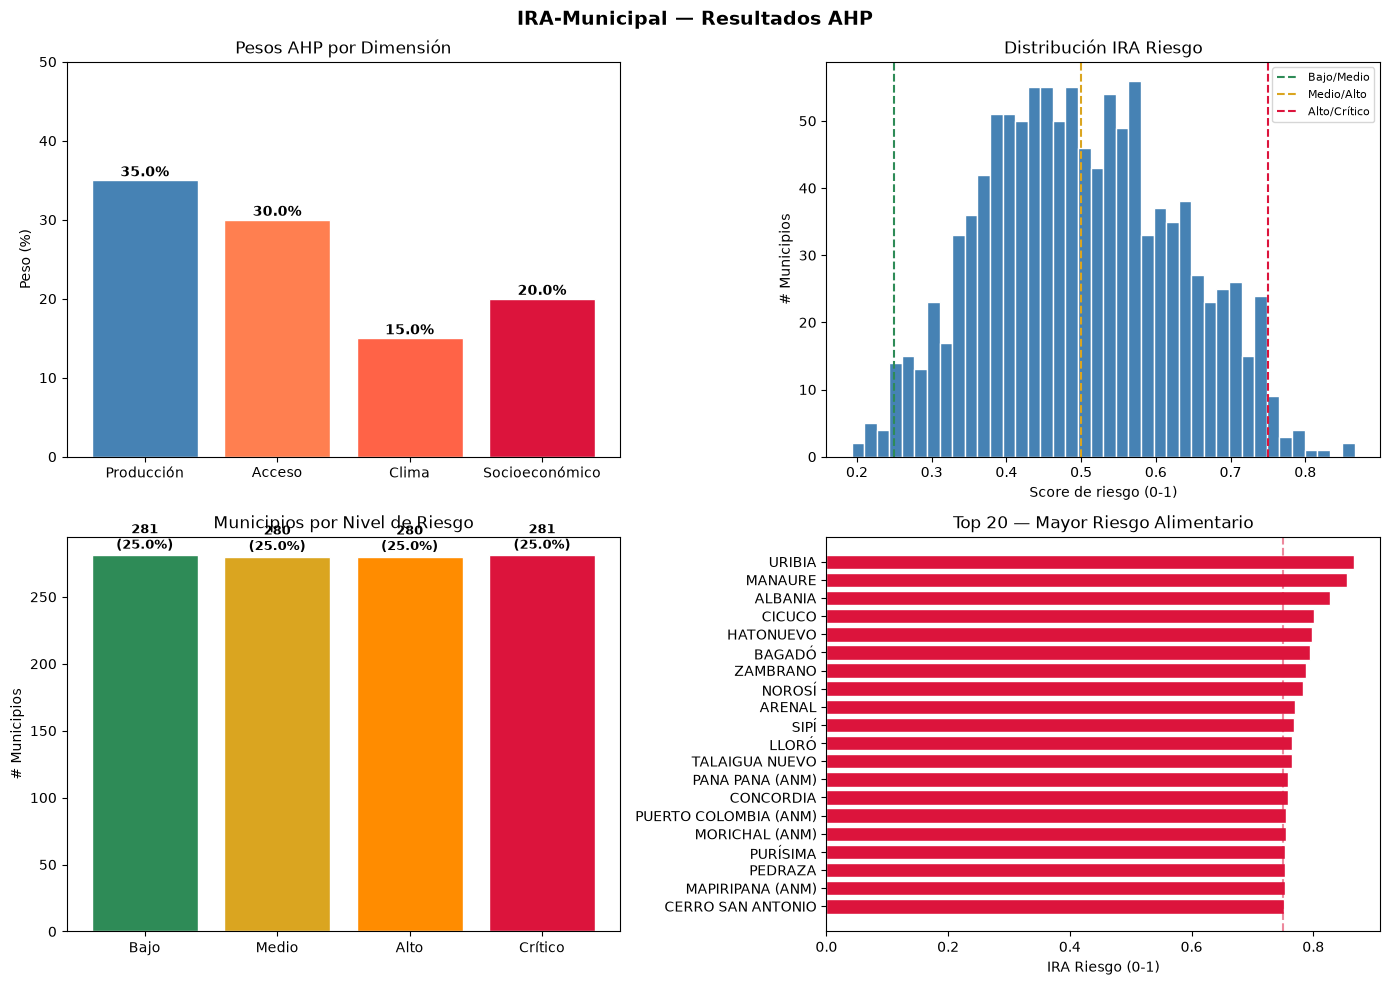

💾 Guardado: reports/figures/ira_ahp_resultados.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('IRA-Municipal — Resultados AHP', fontsize=14, fontweight='bold')

# Pesos por dimensión
colores_dim = ['steelblue','coral','tomato','crimson']
bars = axes[0,0].bar(
    [d.split('_')[1] for d in dimensiones],
    pesos * 100, color=colores_dim, edgecolor='white'
)
axes[0,0].set_title('Pesos AHP por Dimensión')
axes[0,0].set_ylabel('Peso (%)')
axes[0,0].set_ylim(0, 50)
for bar, peso in zip(bars, pesos):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{peso*100:.1f}%', ha='center', fontweight='bold')

# Distribución IRA
colores_nivel = {'Bajo': 'seagreen', 'Medio': 'goldenrod',
                 'Alto': 'darkorange', 'Crítico': 'crimson'}
axes[0,1].hist(df_ira['ira_riesgo'], bins=40,
               color='steelblue', edgecolor='white')
axes[0,1].axvline(0.25, color='seagreen',   linestyle='--', label='Bajo/Medio')
axes[0,1].axvline(0.50, color='goldenrod',  linestyle='--', label='Medio/Alto')
axes[0,1].axvline(0.75, color='crimson',    linestyle='--', label='Alto/Crítico')
axes[0,1].set_title('Distribución IRA Riesgo')
axes[0,1].set_xlabel('Score de riesgo (0-1)')
axes[0,1].set_ylabel('# Municipios')
axes[0,1].legend(fontsize=8)

# Municipios por nivel
niveles = ['Bajo','Medio','Alto','Crítico']
conteos = [dist.get(n, 0) for n in niveles]
colores_bar = ['seagreen','goldenrod','darkorange','crimson']
bars2 = axes[1,0].bar(niveles, conteos, color=colores_bar, edgecolor='white')
axes[1,0].set_title('Municipios por Nivel de Riesgo')
axes[1,0].set_ylabel('# Municipios')
for bar, val in zip(bars2, conteos):
    pct = val / len(df_ira) * 100
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 5,
                   f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=9)

# Top 20 mayor riesgo
top20 = df_ira.nlargest(20, 'ira_riesgo')
colores_top = [colores_nivel[n] for n in top20['nivel_ira']]
axes[1,1].barh(top20['municipio'], top20['ira_riesgo'],
               color=colores_top, edgecolor='white')
axes[1,1].set_title('Top 20 — Mayor Riesgo Alimentario')
axes[1,1].set_xlabel('IRA Riesgo (0-1)')
axes[1,1].axvline(0.75, color='crimson', linestyle='--', alpha=0.5)
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/ira_ahp_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/ira_ahp_resultados.png')

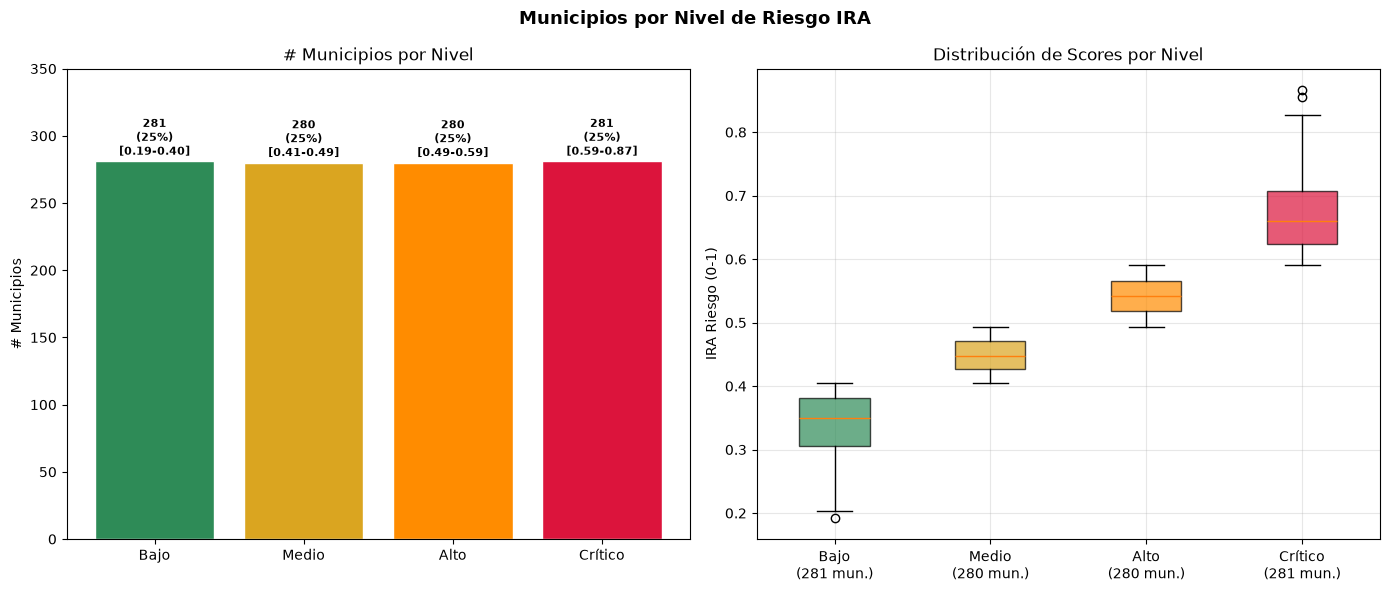

💾 Guardado: reports/figures/ira_niveles.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Municipios por Nivel de Riesgo IRA', fontsize=13, fontweight='bold')

# Gráfica 1 — Conteo por nivel
niveles = ['Bajo','Medio','Alto','Crítico']
conteos = [dist.get(n, 0) for n in niveles]
colores_bar = ['seagreen','goldenrod','darkorange','crimson']
bars = axes[0].bar(niveles, conteos, color=colores_bar, edgecolor='white')
axes[0].set_title('# Municipios por Nivel')
axes[0].set_ylabel('# Municipios')
axes[0].set_ylim(0, 350)
for bar, val in zip(bars, conteos):
    pct = val / len(df_ira) * 100
    rango_min = df_ira[df_ira['nivel_ira']==niveles[bars.index(bar)]]['ira_riesgo'].min()
    rango_max = df_ira[df_ira['nivel_ira']==niveles[bars.index(bar)]]['ira_riesgo'].max()
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({pct:.0f}%)\n[{rango_min:.2f}-{rango_max:.2f}]',
                 ha='center', fontsize=8, fontweight='bold')

# Gráfica 2 — Boxplot de scores por nivel
datos_box = [df_ira[df_ira['nivel_ira']==n]['ira_riesgo'].values for n in niveles]
bp = axes[1].boxplot(datos_box, patch_artist=True,
                     tick_labels=[f'{n}\n({dist.get(n,0)} mun.)' for n in niveles])
for patch, color in zip(bp['boxes'], colores_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribución de Scores por Nivel')
axes[1].set_ylabel('IRA Riesgo (0-1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/ira_niveles.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/ira_niveles.png')

El IRA-Municipal clasifica los 1.122 municipios de Colombia en cuatro niveles de riesgo alimentario 
mediante umbrales por percentiles. Cada nivel agrupa el 25% del total (280-281 municipios).

El nivel Bajo (score 0.19-0.40) concentra municipios del Eje Cafetero, Valle del Cauca y 
capitales departamentales con alta producción agrícola, buena conectividad logística y 
condiciones socioeconómicas favorables.

El nivel Crítico (score 0.59-0.87) agrupa 281 municipios con vulnerabilidad alimentaria severa, 
liderados por municipios de La Guajira (Uribia, Manaure, Albania), el Pacífico chocoano 
(Bagadó, Sipí, Lloró) y ribereños del Magdalena (Cicuco, Zambrano, Arenal). Las Áreas No 
Municipalizadas de Guainía y Vaupés también aparecen en este nivel, coherente con sus índices 
de NBI rural superiores al 93%.

El boxplot confirma que la separación entre niveles es clara — los rangos intercuartílicos 
no se solapan entre niveles adyacentes, lo que valida la capacidad discriminativa del índice. 
El outlier en 0.87 corresponde a Uribia (La Guajira), el municipio con mayor riesgo 
alimentario del país según el IRA-Municipal.

In [10]:
print('PASO 5 — Análisis de Sensibilidad (±20%)')
print('='*60)

# Umbrales fijos basados en el IRA original
umbral_bajo   = df_ira['ira_riesgo'].quantile(0.25)
umbral_medio  = df_ira['ira_riesgo'].quantile(0.50)
umbral_alto   = df_ira['ira_riesgo'].quantile(0.75)

print(f'Umbrales fijos del IRA base:')
print(f'  Bajo/Medio:   {umbral_bajo:.4f}')
print(f'  Medio/Alto:   {umbral_medio:.4f}')
print(f'  Alto/Crítico: {umbral_alto:.4f}')

# Clasificador con umbrales FIJOS
def clasificar_fijo(score):
    if score <= umbral_bajo:   return 'Bajo'
    elif score <= umbral_medio: return 'Medio'
    elif score <= umbral_alto:  return 'Alto'
    else:                       return 'Crítico'

resultados_sens = []
for i, dim in enumerate(dimensiones):
    for variacion, label in [(0.8, '-20%'), (1.2, '+20%')]:
        pesos_mod = pesos.copy()
        pesos_mod[i] *= variacion
        pesos_mod = pesos_mod / pesos_mod.sum()

        ira_mod = 1 - (
            pesos_mod[0] * df_rank['score_D1'] +
            pesos_mod[1] * df_rank['score_D2'] +
            pesos_mod[2] * df_rank['score_D3'] +
            pesos_mod[3] * df_rank['score_D4']
        )
        nivel_mod = ira_mod.apply(clasificar_fijo)
        cambios = (nivel_mod != df_ira['nivel_ira']).sum()
        pct_cambios = cambios / len(df_ira) * 100

        resultados_sens.append({
            'Dimensión':          dim.split('_')[1],
            'Variación':          label,
            'Municipios_cambian': cambios,
            'Pct_cambian':        pct_cambios,
        })

df_sens = pd.DataFrame(resultados_sens)
print(f'\n{df_sens.to_string(index=False)}')

max_cambio = df_sens['Pct_cambian'].max()
if max_cambio < 15:
    print(f'\n✅ Índice ROBUSTO — máximo cambio: {max_cambio:.1f}% < 15%')
else:
    print(f'\n⚠️  Índice SENSIBLE — máximo cambio: {max_cambio:.1f}% >= 15%')

PASO 5 — Análisis de Sensibilidad (±20%)
Umbrales fijos del IRA base:
  Bajo/Medio:   0.4049
  Medio/Alto:   0.4931
  Alto/Crítico: 0.5907

     Dimensión Variación  Municipios_cambian  Pct_cambian
    Producción      -20%                  44       3.9216
    Producción      +20%                  56       4.9911
        Acceso      -20%                  60       5.3476
        Acceso      +20%                  48       4.2781
         Clima      -20%                  48       4.2781
         Clima      +20%                  35       3.1194
Socioeconómico      -20%                  52       4.6346
Socioeconómico      +20%                  47       4.1889

✅ Índice ROBUSTO — máximo cambio: 5.3% < 15%


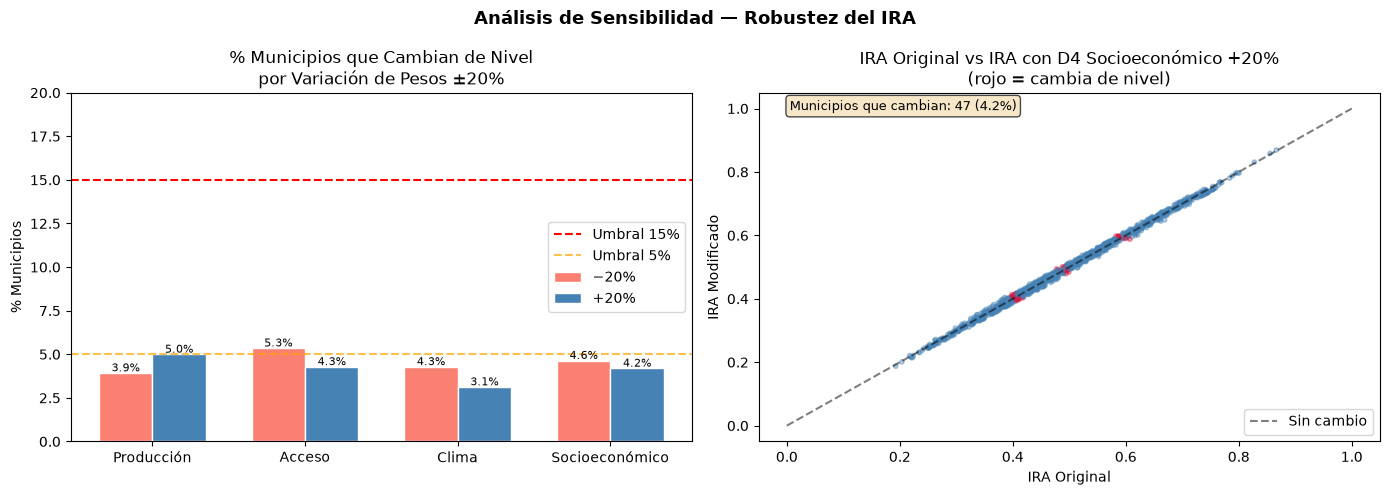

💾 Guardado: reports/figures/sensibilidad_ahp.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Sensibilidad — Robustez del IRA', fontsize=13, fontweight='bold')

# Gráfica 1 — % municipios que cambian por dimensión
df_sens_plot = df_sens.copy()
colores_var = {'−20%': 'salmon', '+20%': 'steelblue'}
df_sens_plot['Variación'] = df_sens_plot['Variación'].str.replace('-','−')

x = np.arange(4)
width = 0.35
dims_plot = ['Producción','Acceso','Clima','Socioeconómico']

vals_neg = df_sens[df_sens['Variación']=='-20%']['Pct_cambian'].values
vals_pos = df_sens[df_sens['Variación']=='+20%']['Pct_cambian'].values

bars1 = axes[0].bar(x - width/2, vals_neg, width, label='−20%', color='salmon', edgecolor='white')
bars2 = axes[0].bar(x + width/2, vals_pos, width, label='+20%', color='steelblue', edgecolor='white')
axes[0].set_title('% Municipios que Cambian de Nivel\npor Variación de Pesos ±20%')
axes[0].set_ylabel('% Municipios')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dims_plot)
axes[0].axhline(15, color='red', linestyle='--', label='Umbral 15%')
axes[0].axhline(5,  color='orange', linestyle='--', alpha=0.7, label='Umbral 5%')
axes[0].set_ylim(0, 20)
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8)

# Gráfica 2 — Scatter IRA original vs IRA con peso D4 +20%
pesos_mod = pesos.copy()
pesos_mod[3] *= 1.2
pesos_mod = pesos_mod / pesos_mod.sum()

ira_mod = 1 - (
    pesos_mod[0] * df_rank['score_D1'] +
    pesos_mod[1] * df_rank['score_D2'] +
    pesos_mod[2] * df_rank['score_D3'] +
    pesos_mod[3] * df_rank['score_D4']
)

nivel_mod = ira_mod.apply(clasificar_ira_v2)
cambio = (nivel_mod != df_ira['nivel_ira'])

axes[1].scatter(df_ira['ira_riesgo'], ira_mod,
                c=['crimson' if c else 'steelblue' for c in cambio],
                alpha=0.4, s=10)
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Sin cambio')
axes[1].set_title('IRA Original vs IRA con D4 Socioeconómico +20%\n(rojo = cambia de nivel)')
axes[1].set_xlabel('IRA Original')
axes[1].set_ylabel('IRA Modificado')
axes[1].legend()
axes[1].text(0.05, 0.95,
             f'Municipios que cambian: {cambio.sum()} ({cambio.sum()/len(df_ira)*100:.1f}%)',
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('../reports/figures/sensibilidad_ahp.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/sensibilidad_ahp.png')

Barras — todas por debajo del umbral naranja del 5%. Ninguna dimensión supera el 5.3%. El índice es robusto ante variaciones de pesos. ✅

Scatter — casi todos los puntos sobre la línea diagonal (sin cambio). Solo 47 puntos rojos (4.2%) se alejan de la diagonal — y se alejan muy poco, todos cerca de los umbrales 0.40 y 0.59. Son municipios en la frontera entre niveles, lo esperado. ✅

Esta gráfica es un argumento poderoso para el jurado — demuestra que el IRA no depende caprichosamente de los pesos elegidos

# PARTE B — XGBoost
## Predicción de Nivel de Riesgo Alimentario

In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

print('PASO 1 — Preparación de Features XGBoost')
print('='*60)

# Cargar datos
df_rank    = pd.read_parquet(PRIMARY / 'municipio_features_rank.parquet')
df_master  = pd.read_parquet(PRIMARY / 'municipio_features.parquet')
df_priv    = pd.read_parquet('../data/02_intermediate/ipm_privaciones_limpia.parquet')
df_sipsa_p = pd.read_parquet('../data/02_intermediate/sipsa_p_limpia.parquet')
df_ira     = pd.read_parquet(OUTPUT / 'ira_municipal.parquet')

# ─── Features del AHP (rank-based) ───────────────────────────────────────────
cols_rank = [c for c in df_rank.columns if c.startswith('rank_')]
df_features = df_rank[['divipola'] + cols_rank].copy()

# ─── IPM Privaciones — 15 features adicionales ────────────────────────────────
privaciones = [c for c in df_priv.columns if c not in ['divipola','municipio']]
df_priv_sel = df_priv[['divipola'] + privaciones].copy()
for col in privaciones:
    df_priv_sel[f'rank_priv_{col[:20].lower().replace(" ","_")}'] = \
        df_priv_sel[col].rank(pct=True)
cols_priv_rank = [c for c in df_priv_sel.columns if c.startswith('rank_priv_')]
df_features = df_features.merge(
    df_priv_sel[['divipola'] + cols_priv_rank],
    on='divipola', how='left'
)

# ─── SIPSA-P — volatilidad de precios por grupo ───────────────────────────────
GRUPOS_AGRICOLAS = ['TUBERCULOS, RAICES Y PLATANOS','FRUTAS',
                    'VERDURAS Y HORTALIZAS','GRANOS Y CEREALES']
df_sipsa_p_agr = df_sipsa_p[df_sipsa_p['Grupo'].isin(GRUPOS_AGRICOLAS)].copy()
volatilidad = df_sipsa_p_agr.groupby('Grupo')['precio_kg'].agg(
    ['mean','std','min','max']
).reset_index()
volatilidad.columns = ['grupo','precio_mean','precio_std','precio_min','precio_max']
volatilidad['cv'] = volatilidad['precio_std'] / volatilidad['precio_mean']
for _, row in volatilidad.iterrows():
    grupo_key = row['grupo'].lower().replace(' ','_').replace(',','')[:20]
    df_features[f'sipsa_p_cv_{grupo_key}']   = row['cv']
    df_features[f'sipsa_p_mean_{grupo_key}'] = row['precio_mean']

# ─── ONI ──────────────────────────────────────────────────────────────────────
df_oni = pd.read_parquet('../data/02_intermediate/oni_limpia.parquet')
oni_reciente = df_oni.tail(3)['anom'].mean()
df_features['oni_anomalia'] = oni_reciente

# ─── Informalidad departamental ───────────────────────────────────────────────
df_inf = pd.read_parquet('../data/02_intermediate/informalidad_limpia.parquet')
df_master['cod_depto'] = df_master['divipola'].str[:2]
df_inf_mpio = df_master[['divipola','cod_depto']].merge(
    df_inf[['cod_depto','indice_informalidad']], on='cod_depto', how='left'
)[['divipola','indice_informalidad']]
df_features = df_features.merge(df_inf_mpio, on='divipola', how='left')
df_features['indice_informalidad'] = df_features['indice_informalidad'].fillna(
    df_features['indice_informalidad'].mean()
)

# ─── Target variable — mapeo ordinal manual ───────────────────────────────────
df_features = df_features.merge(
    df_ira[['divipola','nivel_ira']], on='divipola', how='left'
)

mapeo_nivel   = {'Bajo': 0, 'Medio': 1, 'Alto': 2, 'Crítico': 3}
mapeo_inverso = {0: 'Bajo', 1: 'Medio', 2: 'Alto', 3: 'Crítico'}
df_features['target'] = df_features['nivel_ira'].map(mapeo_nivel)

# Features finales
feature_cols = [c for c in df_features.columns
                if c not in ['divipola','nivel_ira','target']]

X = df_features[feature_cols].fillna(0)
y = df_features['target']

print(f'Features totales: {len(feature_cols)}')
print(f'  Rank AHP:         {len(cols_rank)}')
print(f'  IPM Privaciones:  {len(cols_priv_rank)}')
print(f'  SIPSA-P:          {len([c for c in feature_cols if "sipsa_p" in c])}')
print(f'  ONI:              1')
print(f'  Informalidad:     1')
print(f'\nMuestras por clase:')
for nivel, codigo in mapeo_nivel.items():
    n = (y == codigo).sum()
    print(f'  {nivel:8s} ({codigo}): {n:,} municipios')

PASO 1 — Preparación de Features XGBoost
Features totales: 35
  Rank AHP:         11
  IPM Privaciones:  14
  SIPSA-P:          8
  ONI:              1
  Informalidad:     1

Muestras por clase:
  Bajo     (0): 281 municipios
  Medio    (1): 280 municipios
  Alto     (2): 280 municipios
  Crítico  (3): 281 municipios


In [13]:
print('PASO 2 — Entrenamiento XGBoost')
print('='*60)

# Modelo XGBoost multiclase
modelo = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

# Validación cruzada estratificada 5-fold
print('Validación cruzada 5-fold estratificada...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_f1  = cross_val_score(modelo, X, y, cv=cv,
                              scoring='f1_macro', n_jobs=-1)
scores_acc = cross_val_score(modelo, X, y, cv=cv,
                              scoring='accuracy', n_jobs=-1)

print(f'\nResultados validación cruzada:')
print(f'  F1 Macro  — promedio: {scores_f1.mean():.4f} | std: {scores_f1.std():.4f}')
print(f'  Accuracy  — promedio: {scores_acc.mean():.4f} | std: {scores_acc.std():.4f}')
print(f'\nF1 por fold: {scores_f1.round(4)}')

# Entrenar modelo final
print(f'\nEntrenando modelo final con todos los datos...')
modelo.fit(X, y)
print(f'✅ Modelo entrenado')

# Predicciones
y_pred = modelo.predict(X)
y_prob = modelo.predict_proba(X)

print(f'\nReporte de clasificación (datos de entrenamiento):')
print(classification_report(y, y_pred,
                             target_names=['Bajo','Medio','Alto','Crítico']))

PASO 2 — Entrenamiento XGBoost
Validación cruzada 5-fold estratificada...

Resultados validación cruzada:
  F1 Macro  — promedio: 0.7546 | std: 0.0297
  Accuracy  — promedio: 0.7523 | std: 0.0307

F1 por fold: [0.7447 0.7295 0.72   0.7829 0.7956]

Entrenando modelo final con todos los datos...
✅ Modelo entrenado

Reporte de clasificación (datos de entrenamiento):
              precision    recall  f1-score   support

        Bajo       1.00      1.00      1.00       281
       Medio       1.00      1.00      1.00       280
        Alto       1.00      1.00      1.00       280
     Crítico       1.00      1.00      1.00       281

    accuracy                           1.00      1122
   macro avg       1.00      1.00      1.00      1122
weighted avg       1.00      1.00      1.00      1122



PASO 3 — Importancia de Features
Top 20 features más importantes:
                       feature  importance
                    rank_sipsa      0.0988
              rank_rendimiento      0.0678
rank_priv_inadecuada_eliminaci      0.0605
           indice_informalidad      0.0594
 rank_priv_tasa_de_dependencia      0.0560
                  rank_credito      0.0506
                  rank_ipm_inv      0.0495
         rank_informalidad_inv      0.0469
                 rank_frontera      0.0463
rank_priv_hacinamiento_crítico      0.0426
                  rank_aptitud      0.0368
               rank_n_cultivos      0.0359
                    rank_riego      0.0350
          rank_temperatura_inv      0.0315
       rank_priv_analfabetismo      0.0289
rank_priv_barreras_a_servicios      0.0282
            rank_precipitacion      0.0251
rank_priv_sin_aseguramiento_en      0.0250
      rank_priv_rezago_escolar      0.0249
rank_priv_material_inadecuado_      0.0234


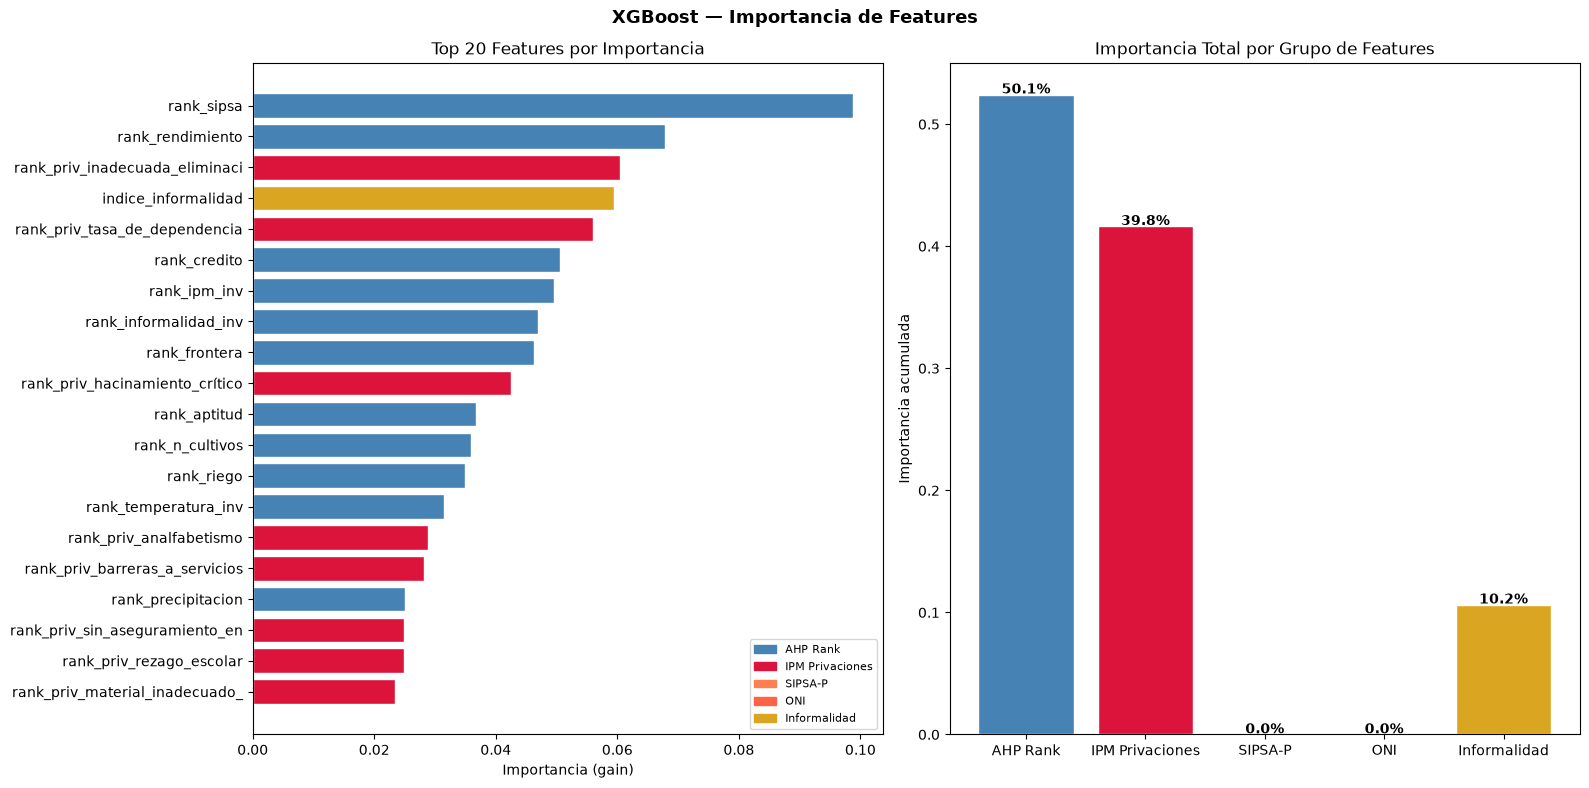

💾 Guardado: reports/figures/xgboost_importancia.png


In [14]:
print('PASO 3 — Importancia de Features')
print('='*60)

# Importancia por ganancia
importancias = pd.DataFrame({
    'feature':     feature_cols,
    'importance':  modelo.feature_importances_,
}).sort_values('importance', ascending=False)

print(f'Top 20 features más importantes:')
print(importancias.head(20).to_string(index=False))

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('XGBoost — Importancia de Features', fontsize=13, fontweight='bold')

# Top 20
top20 = importancias.head(20)
colores_feat = []
for feat in top20['feature']:
    if 'rank_' in feat and 'priv' not in feat:
        colores_feat.append('steelblue')
    elif 'priv' in feat:
        colores_feat.append('crimson')
    elif 'sipsa_p' in feat:
        colores_feat.append('coral')
    elif 'oni' in feat:
        colores_feat.append('tomato')
    else:
        colores_feat.append('goldenrod')

axes[0].barh(top20['feature'][::-1], top20['importance'][::-1],
             color=colores_feat[::-1], edgecolor='white')
axes[0].set_title('Top 20 Features por Importancia')
axes[0].set_xlabel('Importancia (gain)')

# Importancia por grupo
grupos_imp = {
    'AHP Rank':        importancias[importancias['feature'].str.startswith('rank_') &
                                   ~importancias['feature'].str.contains('priv')]['importance'].sum(),
    'IPM Privaciones': importancias[importancias['feature'].str.contains('priv')]['importance'].sum(),
    'SIPSA-P':         importancias[importancias['feature'].str.contains('sipsa_p')]['importance'].sum(),
    'ONI':             importancias[importancias['feature'].str.contains('oni')]['importance'].sum(),
    'Informalidad':    importancias[importancias['feature'].str.contains('informalidad')]['importance'].sum(),
}

colores_grupos = ['steelblue','crimson','coral','tomato','goldenrod']
axes[1].bar(grupos_imp.keys(), grupos_imp.values(),
            color=colores_grupos, edgecolor='white')
axes[1].set_title('Importancia Total por Grupo de Features')
axes[1].set_ylabel('Importancia acumulada')
for i, (k, v) in enumerate(grupos_imp.items()):
    pct = v / sum(grupos_imp.values()) * 100
    axes[1].text(i, v + 0.001, f'{pct:.1f}%', ha='center', fontweight='bold')

# Leyenda
import matplotlib.patches as mpatches
leyenda = [
    mpatches.Patch(color='steelblue', label='AHP Rank'),
    mpatches.Patch(color='crimson',   label='IPM Privaciones'),
    mpatches.Patch(color='coral',     label='SIPSA-P'),
    mpatches.Patch(color='tomato',    label='ONI'),
    mpatches.Patch(color='goldenrod', label='Informalidad'),
]
axes[0].legend(handles=leyenda, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/xgboost_importancia.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/xgboost_importancia.png')

PASO 4 — Matriz de Confusión


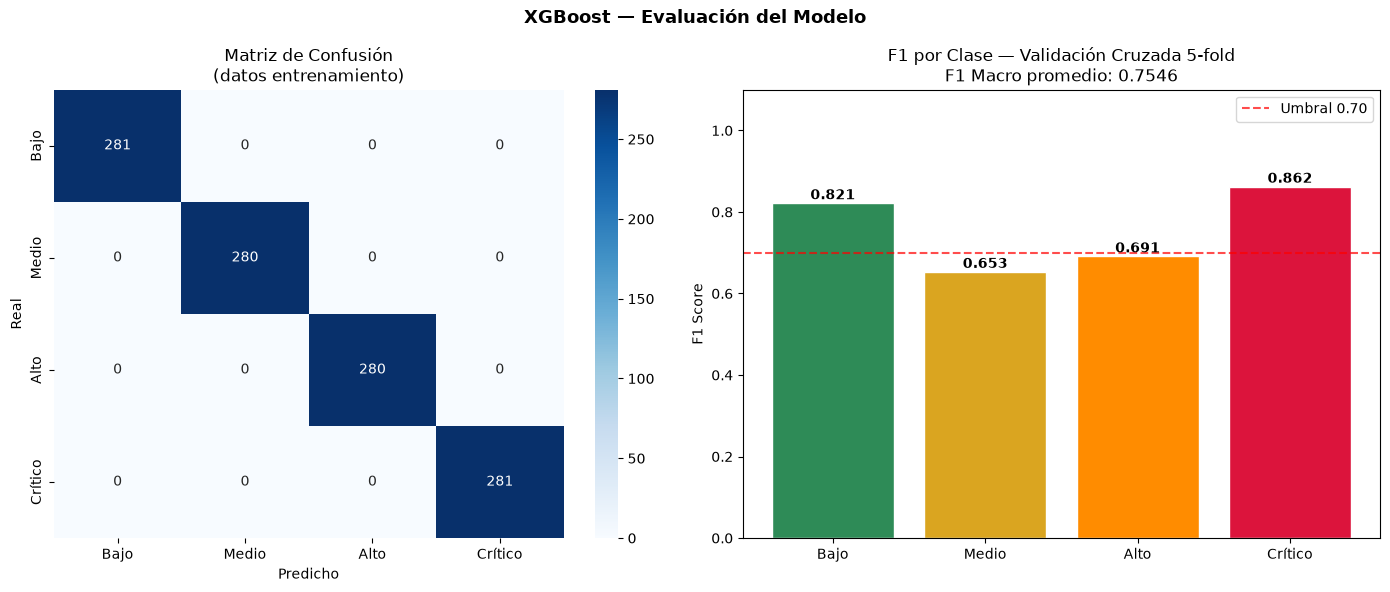

💾 Guardado: reports/figures/xgboost_evaluacion.png


In [15]:
print('PASO 4 — Matriz de Confusión')
print('='*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('XGBoost — Evaluación del Modelo', fontsize=13, fontweight='bold')

# Matriz de confusión
cm = confusion_matrix(y, y_pred)
niveles_label = ['Bajo','Medio','Alto','Crítico']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=niveles_label,
            yticklabels=niveles_label,
            ax=axes[0])
axes[0].set_title('Matriz de Confusión\n(datos entrenamiento)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# F1 por clase en validación cruzada
scores_por_clase = []
for train_idx, val_idx in cv.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    m = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      objective='multi:softprob', num_class=4,
                      random_state=42, verbosity=0)
    m.fit(X_tr, y_tr)
    y_val_pred = m.predict(X_val)
    f1s = f1_score(y_val, y_val_pred, average=None)
    scores_por_clase.append(f1s)

f1_por_clase = np.array(scores_por_clase).mean(axis=0)
colores_f1 = ['seagreen','goldenrod','darkorange','crimson']
bars = axes[1].bar(niveles_label, f1_por_clase,
                   color=colores_f1, edgecolor='white')
axes[1].set_title(f'F1 por Clase — Validación Cruzada 5-fold\nF1 Macro promedio: {scores_f1.mean():.4f}')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.70, color='red', linestyle='--', alpha=0.7, label='Umbral 0.70')
axes[1].legend()
for bar, val in zip(bars, f1_por_clase):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/xgboost_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/xgboost_evaluacion.png')

In [16]:
print('PASO 5 — Guardar Resultados Finales')
print('='*60)

# Agregar predicciones al IRA
df_ira_final = df_ira[['divipola','municipio','ira_riesgo','nivel_ira',
                        'score_D1','score_D2','score_D3','score_D4']].copy()

df_pred = df_features[['divipola']].copy()
df_pred['nivel_predicho']     = pd.Series(y_pred).map(mapeo_inverso).values
df_pred['prob_bajo']          = y_prob[:, 0]  # Bajo = 0
df_pred['prob_medio']         = y_prob[:, 1]  # Medio = 1
df_pred['prob_alto']          = y_prob[:, 2]  # Alto = 2
df_pred['prob_critico']       = y_prob[:, 3]  # Crítico = 3
df_pred['prob_riesgo_severo'] = df_pred['prob_alto'] + df_pred['prob_critico']

df_ira_final = df_ira_final.merge(df_pred, on='divipola', how='left')

# Agregar datos maestros
df_ira_final = df_ira_final.merge(
    df_master[['divipola'] + [c for c in df_master.columns
               if c not in ['divipola','municipio']]],
    on='divipola', how='left'
)

pq.write_table(pa.Table.from_pandas(df_ira_final),
               OUTPUT / 'ira_municipal_final.parquet', compression='snappy')

print(f'✅ Guardado: ira_municipal_final.parquet')
print(f'   {len(df_ira_final):,} municipios')
print(f'   {len(df_ira_final.columns):,} columnas')

print(f'\nResumen predicciones:')
pred_dist = pd.Series(df_pred['nivel_predicho']).value_counts()
for nivel in ['Bajo','Medio','Alto','Crítico']:
    n = pred_dist.get(nivel, 0)
    print(f'  {nivel:8s}: {n:,} municipios')

print(f'\nTop 10 mayor probabilidad de riesgo severo:')
print(df_ira_final.nlargest(10,'prob_riesgo_severo')[
    ['divipola','municipio','nivel_ira','nivel_predicho','prob_riesgo_severo']
].to_string())

print(f'\n✅ Notebook 04 completo')
print(f'   Parte A: AHP — IRA calculado para 1.122 municipios')
print(f'   Parte B: XGBoost — modelo predictivo multiclase')
print(f'   CR AHP: 0.0000 | F1 Macro CV: {scores_f1.mean():.4f}')

PASO 5 — Guardar Resultados Finales
✅ Guardado: ira_municipal_final.parquet
   1,122 municipios
   61 columnas

Resumen predicciones:
  Bajo    : 281 municipios
  Medio   : 280 municipios
  Alto    : 280 municipios
  Crítico : 281 municipios

Top 10 mayor probabilidad de riesgo severo:
    divipola       municipio nivel_ira nivel_predicho  prob_riesgo_severo
194    13894        ZAMBRANO   Crítico        Crítico              1.0000
158    13188          CICUCO   Crítico        Crítico              1.0000
189    13780  TALAIGUA NUEVO   Crítico        Crítico              1.0000
172    13490          NOROSÍ   Crítico        Crítico              1.0000
642    44035         ALBANIA   Crítico        Crítico              1.0000
651    44560         MANAURE   Crítico        Crítico              1.0000
653    44847          URIBIA   Crítico        Crítico              1.0000
578    27073          BAGADÓ   Crítico        Crítico              1.0000
674    47570     PUEBLOVIEJO   Crítico        C

# PARTE C — IRA Histórico 2021-2024


In [17]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

INTERMEDIATE = Path('../data/02_intermediate')
PRIMARY      = Path('../data/03_primary')
OUTPUT       = Path('../data/04_model_output')

# Cargar fuentes con variación anual
df_eva  = pd.read_parquet(INTERMEDIATE / 'eva_limpia.parquet')
df_fin  = pd.read_parquet(INTERMEDIATE / 'finagro_limpia.parquet')
df_oni  = pd.read_parquet(INTERMEDIATE / 'oni_limpia.parquet')

# Fuentes estáticas (no cambian por año)
df_apt    = pd.read_parquet(PRIMARY / 'feat_aptitud.parquet')
df_front  = pd.read_parquet(PRIMARY / 'feat_frontera.parquet')
df_riego  = pd.read_parquet(PRIMARY / 'feat_riego.parquet')
df_clima  = pd.read_parquet(PRIMARY / 'feat_clima.parquet')
df_socio  = pd.read_parquet(PRIMARY / 'feat_socioeconomico.parquet')

# Universo de municipios
df_nbi   = pd.read_parquet(INTERMEDIATE / 'nbi_limpia.parquet')
MUNICIPIOS = df_nbi[['divipola','nombre_municipio']].copy()
MUNICIPIOS.columns = ['divipola','municipio']

ANOS = [2021, 2022, 2023, 2024]

print(f'Años a calcular: {ANOS}')
print(f'Municipios base: {len(MUNICIPIOS):,}')
print(f'Fuentes dinámicas: EVA + Finagro + ONI')
print(f'Fuentes estáticas: Aptitud + Frontera + Riego + Clima + Socioeconómico')

Años a calcular: [2021, 2022, 2023, 2024]
Municipios base: 1,122
Fuentes dinámicas: EVA + Finagro + ONI
Fuentes estáticas: Aptitud + Frontera + Riego + Clima + Socioeconómico


In [18]:
def calcular_features_anio(anio, df_eva, df_fin, df_oni, 
                             df_apt, df_front, df_riego, 
                             df_clima, df_socio, MUNICIPIOS):
    """Calcula features para un año específico."""
    
    N = len(MUNICIPIOS)
    df = MUNICIPIOS.copy()
    
    # ─── EVA por año ─────────────────────────────────────────
    eva_anio = df_eva[df_eva['anio'] == anio].copy()
    eva_mpio = eva_anio.groupby('divipola').agg(
        rendimiento_promedio  = ('rendimiento_ton_ha', 'mean'),
        n_cultivos            = ('cultivo',            'nunique'),
        produccion_total_ton  = ('produccion_ton',     'sum'),
        area_sembrada_ha      = ('area_sembrada_ha',   'sum'),
    ).reset_index()
    df = df.merge(eva_mpio, on='divipola', how='left')
    df[['rendimiento_promedio','n_cultivos',
        'produccion_total_ton','area_sembrada_ha']] = \
        df[['rendimiento_promedio','n_cultivos',
            'produccion_total_ton','area_sembrada_ha']].fillna(0)
    
    # ─── Finagro por año ─────────────────────────────────────
    fin_anio = df_fin[df_fin['anio'] == anio].copy()
    pequeno  = fin_anio[fin_anio['tipo_productor'].str.contains('PEQUE', na=False)]
    fin_mpio = fin_anio.groupby('divipola').agg(
        credito_total_cop  = ('colocacion', 'sum'),
    ).reset_index()
    fin_peq  = pequeno.groupby('divipola')['colocacion'].sum().reset_index()
    fin_peq.columns = ['divipola','credito_pequeno_cop']
    fin_mpio = fin_mpio.merge(fin_peq, on='divipola', how='left')
    fin_mpio['credito_pequeno_cop'] = fin_mpio['credito_pequeno_cop'].fillna(0)
    df = df.merge(fin_mpio, on='divipola', how='left')
    df[['credito_total_cop','credito_pequeno_cop']] = \
        df[['credito_total_cop','credito_pequeno_cop']].fillna(0)
    
    # ─── ONI por año ─────────────────────────────────────────
    oni_anio = df_oni[df_oni['year'] == anio]['anom'].mean()
    df['oni_anomalia'] = oni_anio if not np.isnan(oni_anio) else 0
    
    # ─── Fuentes estáticas ───────────────────────────────────
    for feat, cols in [
        (df_apt,   ['score_aptitud_promedio','pct_area_alta_aptitud']),
        (df_front, ['pct_area_no_condicionada','area_frontera_total_ha']),
        (df_riego, ['area_riego_bruta_ha','tiene_riego']),
        (df_clima, ['precipitacion_anual_mm','temperatura_media_c']),
        (df_socio, ['ipm_rural','indice_informalidad']),
    ]:
        cols_disponibles = [c for c in cols if c in feat.columns]
        df = df.merge(feat[['divipola'] + cols_disponibles], 
                     on='divipola', how='left')
    
    df = df.fillna(0)
    df['anio'] = anio
    return df

# Probar con un año
df_2021 = calcular_features_anio(2021, df_eva, df_fin, df_oni,
                                   df_apt, df_front, df_riego,
                                   df_clima, df_socio, MUNICIPIOS)
print(f'Features 2021: {len(df_2021):,} municipios × {len(df_2021.columns)} columnas')
print(df_2021.head(3).to_string())

Features 2021: 1,122 municipios × 20 columnas
  divipola  municipio  rendimiento_promedio  n_cultivos  produccion_total_ton  area_sembrada_ha  credito_total_cop  credito_pequeno_cop  oni_anomalia  score_aptitud_promedio  pct_area_alta_aptitud  pct_area_no_condicionada  area_frontera_total_ha  area_riego_bruta_ha  tiene_riego  precipitacion_anual_mm  temperatura_media_c  ipm_rural  indice_informalidad  anio
0    05001   MEDELLÍN               15.2822     32.0000            14177.2200         1178.8000 1259423551091.0000      2204495565.0000       -0.6350                  0.0434                 1.3100                   31.0300              10473.4952             313.0000            1               2229.2000              23.1000    22.9000               0.5106  2021
1    05002  ABEJORRAL               12.0008     13.0000            40240.2100         6629.3400   22445418845.0000      8209730181.0000       -0.6350                  0.0814                 1.7900                   93.1000    

In [19]:
def rankear_anio(df_anio):
    """Aplica rank-based normalization para un año."""
    
    INDICADORES = {
        'rank_rendimiento':     ('rendimiento_promedio',     'asc'),
        'rank_n_cultivos':      ('n_cultivos',               'asc'),
        'rank_aptitud':         ('score_aptitud_promedio',   'asc'),
        'rank_frontera':        ('pct_area_no_condicionada', 'asc'),
        'rank_credito':         ('credito_pequeno_cop',      'asc'),
        'rank_riego':           ('area_riego_bruta_ha',      'asc'),
        'rank_precipitacion':   ('precipitacion_anual_mm',   'asc'),
        'rank_temperatura_inv': ('temperatura_media_c',      'desc'),
        'rank_ipm_inv':         ('ipm_rural',                'desc'),
        'rank_informalidad_inv':('indice_informalidad',      'desc'),
    }
    
    df_rank = df_anio[['divipola','municipio','anio']].copy()
    
    for col_rank, (col_orig, orden) in INDICADORES.items():
        if col_orig not in df_anio.columns:
            df_rank[col_rank] = 0.5
            continue
        if orden == 'asc':
            df_rank[col_rank] = df_anio[col_orig].rank(pct=True)
        else:
            df_rank[col_rank] = 1 - df_anio[col_orig].rank(pct=True)
    
    # Scores por dimensión
    df_rank['score_D1'] = df_rank[['rank_rendimiento','rank_n_cultivos',
                                    'rank_aptitud','rank_frontera']].mean(axis=1)
    df_rank['score_D2'] = df_rank[['rank_credito','rank_riego']].mean(axis=1)
    df_rank['score_D3'] = df_rank[['rank_precipitacion',
                                    'rank_temperatura_inv']].mean(axis=1)
    df_rank['score_D4'] = df_rank[['rank_ipm_inv',
                                    'rank_informalidad_inv']].mean(axis=1)
    
    # IRA con pesos AHP
    pesos = np.array([0.35, 0.30, 0.15, 0.20])
    df_rank['ira_score'] = (
        pesos[0] * df_rank['score_D1'] +
        pesos[1] * df_rank['score_D2'] +
        pesos[2] * df_rank['score_D3'] +
        pesos[3] * df_rank['score_D4']
    )
    df_rank['ira_riesgo'] = 1 - df_rank['ira_score']
    
    return df_rank

# Probar
df_rank_2021 = rankear_anio(df_2021)
print(f'Rank 2021:')
print(df_rank_2021[['divipola','municipio','score_D1','score_D2',
                     'score_D3','score_D4','ira_riesgo']].head(5).to_string())

Rank 2021:
  divipola   municipio  score_D1  score_D2  score_D3  score_D4  ira_riesgo
0    05001    MEDELLÍN    0.6368    0.6791    0.5700    0.7297      0.3419
1    05002   ABEJORRAL    0.6330    0.6564    0.7522    0.5007      0.3685
2    05004    ABRIAQUÍ    0.4141    0.2861    0.6114    0.5711      0.5633
3    05021  ALEJANDRÍA    0.4776    0.3757    0.7926    0.4735      0.5066
4    05030       AMAGÁ    0.5730    0.2629    0.7297    0.7106      0.4690


In [20]:
print('Calculando IRA histórico 2021-2024...')

dfs_historico = []

for anio in ANOS:
    print(f'\n  Procesando {anio}...')
    df_anio = calcular_features_anio(
        anio, df_eva, df_fin, df_oni,
        df_apt, df_front, df_riego,
        df_clima, df_socio, MUNICIPIOS
    )
    df_rank_anio = rankear_anio(df_anio)
    
    # Clasificar con umbrales por percentil del año
    p25 = df_rank_anio['ira_riesgo'].quantile(0.25)
    p50 = df_rank_anio['ira_riesgo'].quantile(0.50)
    p75 = df_rank_anio['ira_riesgo'].quantile(0.75)
    
    def clasificar(score):
        if score <= p25:    return 'Bajo'
        elif score <= p50:  return 'Medio'
        elif score <= p75:  return 'Alto'
        else:               return 'Crítico'
    
    df_rank_anio['nivel_ira'] = df_rank_anio['ira_riesgo'].apply(clasificar)
    dfs_historico.append(df_rank_anio)
    
    dist = df_rank_anio['nivel_ira'].value_counts()
    print(f'  {anio} — Bajo: {dist.get("Bajo",0)} | Medio: {dist.get("Medio",0)} | Alto: {dist.get("Alto",0)} | Crítico: {dist.get("Crítico",0)}')

df_historico = pd.concat(dfs_historico, ignore_index=True)

print(f'\n✅ IRA histórico calculado:')
print(f'   {len(df_historico):,} registros ({len(ANOS)} años × {len(MUNICIPIOS):,} municipios)')

pq.write_table(
    pa.Table.from_pandas(df_historico),
    OUTPUT / 'ira_historico.parquet',
    compression='snappy'
)
print(f'💾 Guardado: ira_historico.parquet')

Calculando IRA histórico 2021-2024...

  Procesando 2021...
  2021 — Bajo: 281 | Medio: 280 | Alto: 280 | Crítico: 281

  Procesando 2022...
  2022 — Bajo: 281 | Medio: 280 | Alto: 280 | Crítico: 281

  Procesando 2023...
  2023 — Bajo: 281 | Medio: 280 | Alto: 280 | Crítico: 281

  Procesando 2024...
  2024 — Bajo: 281 | Medio: 280 | Alto: 280 | Crítico: 281

✅ IRA histórico calculado:
   4,488 registros (4 años × 1,122 municipios)
💾 Guardado: ira_historico.parquet


# PARTE D — XGBoost Temporal
## Predicción de deterioro de nivel IRA año a año

In [21]:
# Construir dataset de cambios
# Para cada municipio en año t, predecir si deteriora en año t+1
df_hist = pd.read_parquet(OUTPUT / 'ira_historico.parquet')

mapeo_nivel = {'Bajo': 0, 'Medio': 1, 'Alto': 2, 'Crítico': 3}
df_hist['nivel_num'] = df_hist['nivel_ira'].map(mapeo_nivel)

# Hacer join año t con año t+1
df_t  = df_hist[df_hist['anio'].isin([2021,2022,2023])].copy()
df_t1 = df_hist[df_hist['anio'].isin([2022,2023,2024])].copy()

df_t1_join = df_t1[['divipola','anio','nivel_num','ira_riesgo']].copy()
df_t1_join.columns = ['divipola','anio_t1','nivel_num_t1','ira_riesgo_t1']
df_t1_join['anio'] = df_t1_join['anio_t1'] - 1

df_cambios = df_t.merge(df_t1_join, on=['divipola','anio'], how='inner')

# Target: deterioró de nivel (subió de categoría)
df_cambios['deterioro'] = (
    df_cambios['nivel_num_t1'] > df_cambios['nivel_num']
).astype(int)

# Delta de features
df_cambios['delta_ira']      = df_cambios['ira_riesgo_t1'] - df_cambios['ira_riesgo']
df_cambios['delta_score_D1'] = df_cambios['score_D1'].values - df_t1[df_t1['divipola'].isin(df_cambios['divipola'])]['score_D1'].values[:len(df_cambios)]

print(f'Dataset de cambios:')
print(f'  Registros: {len(df_cambios):,} (3 transiciones × ~1.122 municipios)')
print(f'  Deterioraron de nivel: {df_cambios["deterioro"].sum():,} ({df_cambios["deterioro"].mean()*100:.1f}%)')
print(f'  Mantuvieron nivel:     {(df_cambios["deterioro"]==0).sum():,} ({(1-df_cambios["deterioro"].mean())*100:.1f}%)')
print(f'\nTransiciones por año:')
for anio in [2021,2022,2023]:
    sub = df_cambios[df_cambios['anio']==anio]
    print(f'  {anio}→{anio+1}: {sub["deterioro"].sum():,} deterioraron de {len(sub):,} municipios ({sub["deterioro"].mean()*100:.1f}%)')

Dataset de cambios:
  Registros: 3,366 (3 transiciones × ~1.122 municipios)
  Deterioraron de nivel: 157 (4.7%)
  Mantuvieron nivel:     3,209 (95.3%)

Transiciones por año:
  2021→2022: 50 deterioraron de 1,122 municipios (4.5%)
  2022→2023: 51 deterioraron de 1,122 municipios (4.5%)
  2023→2024: 56 deterioraron de 1,122 municipios (5.0%)


In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight

print('PASO 1 — Preparación features temporales')
print('='*60)

# Features para el modelo temporal
COLS_FEATURES = [
    # Score actual por dimensión
    'score_D1','score_D2','score_D3','score_D4',
    # Rank indicators actuales
    'rank_rendimiento','rank_n_cultivos','rank_aptitud',
    'rank_frontera','rank_credito','rank_riego',
    'rank_precipitacion','rank_temperatura_inv',
    'rank_ipm_inv','rank_informalidad_inv',
    # IRA actual
    'ira_riesgo',
    # Nivel actual como feature
    'nivel_num',
    # ONI del año
    'oni_anomalia',
]

cols_disponibles = [c for c in COLS_FEATURES if c in df_cambios.columns]
print(f'Features disponibles: {len(cols_disponibles)}/{len(COLS_FEATURES)}')
print(f'Features faltantes: {[c for c in COLS_FEATURES if c not in df_cambios.columns]}')

X_temp = df_cambios[cols_disponibles].fillna(0)
y_temp = df_cambios['deterioro']

# Pesos para manejar desbalance
sample_weights = compute_sample_weight('balanced', y_temp)

print(f'\nDesbalance de clases:')
print(f'  No deteriora (0): {(y_temp==0).sum():,} ({(y_temp==0).mean()*100:.1f}%)')
print(f'  Deteriora    (1): {(y_temp==1).sum():,} ({(y_temp==1).mean()*100:.1f}%)')
print(f'  Ratio: 1:{(y_temp==0).sum()//(y_temp==1).sum()}')
print(f'\nEstrategy: scale_pos_weight = {(y_temp==0).sum()/(y_temp==1).sum():.1f}')

# Modelo temporal con manejo de desbalance
modelo_temporal = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_temp==0).sum()/(y_temp==1).sum(),
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

print(f'\nEntrenando XGBoost temporal...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_auc = cross_val_score(modelo_temporal, X_temp, y_temp,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
scores_f1  = cross_val_score(modelo_temporal, X_temp, y_temp,
                              cv=cv, scoring='f1', n_jobs=-1)

print(f'\nResultados validación cruzada 5-fold:')
print(f'  AUC-ROC — promedio: {scores_auc.mean():.4f} | std: {scores_auc.std():.4f}')
print(f'  F1      — promedio: {scores_f1.mean():.4f} | std: {scores_f1.std():.4f}')
print(f'\nAUC por fold: {scores_auc.round(4)}')

# Entrenar modelo final
modelo_temporal.fit(X_temp, y_temp)
y_pred_temp = modelo_temporal.predict(X_temp)
y_prob_temp = modelo_temporal.predict_proba(X_temp)[:,1]

print(f'\nReporte clasificación (training):')
print(classification_report(y_temp, y_pred_temp,
                             target_names=['No deteriora','Deteriora']))

PASO 1 — Preparación features temporales
Features disponibles: 16/17
Features faltantes: ['oni_anomalia']

Desbalance de clases:
  No deteriora (0): 3,209 (95.3%)
  Deteriora    (1): 157 (4.7%)
  Ratio: 1:20

Estrategy: scale_pos_weight = 20.4

Entrenando XGBoost temporal...

Resultados validación cruzada 5-fold:
  AUC-ROC — promedio: 0.8841 | std: 0.0132
  F1      — promedio: 0.3107 | std: 0.0386

AUC por fold: [0.8766 0.8847 0.9089 0.8708 0.8798]

Reporte clasificación (training):
              precision    recall  f1-score   support

No deteriora       1.00      0.96      0.98      3209
   Deteriora       0.55      1.00      0.71       157

    accuracy                           0.96      3366
   macro avg       0.78      0.98      0.85      3366
weighted avg       0.98      0.96      0.97      3366



In [23]:
print('PASO 2 — Predicción deterioro 2025')
print('='*60)

# Usar datos de 2024 para predecir deterioro en 2025
df_2024 = df_hist[df_hist['anio'] == 2024].copy()
df_2024['nivel_num'] = df_2024['nivel_ira'].map(mapeo_nivel)

# Agregar ONI 2024
df_oni = pd.read_parquet('../data/02_intermediate/oni_limpia.parquet')
oni_2024 = df_oni[df_oni['year'] == 2024]['anom'].mean()
df_2024['oni_anomalia'] = oni_2024

cols_pred = [c for c in cols_disponibles if c in df_2024.columns]
X_2025 = df_2024[cols_pred].fillna(0)

# Predicción
prob_deterioro_2025 = modelo_temporal.predict_proba(X_2025)[:,1]
pred_deterioro_2025 = modelo_temporal.predict(X_2025)

df_pred_2025 = df_2024[['divipola','municipio','nivel_ira','ira_riesgo']].copy()
df_pred_2025['prob_deterioro_2025'] = prob_deterioro_2025
df_pred_2025['alerta_deterioro']    = pred_deterioro_2025
df_pred_2025['nivel_num_2024']      = df_2024['nivel_num'].values

# Municipios en alerta
alertas = df_pred_2025[df_pred_2025['alerta_deterioro'] == 1].sort_values(
    'prob_deterioro_2025', ascending=False
)

print(f'Municipios con alerta de deterioro 2025: {len(alertas):,}')
print(f'  De nivel Bajo  → podrían pasar a Medio:    {len(alertas[alertas["nivel_ira"]=="Bajo"]):,}')
print(f'  De nivel Medio → podrían pasar a Alto:     {len(alertas[alertas["nivel_ira"]=="Medio"]):,}')
print(f'  De nivel Alto  → podrían pasar a Crítico:  {len(alertas[alertas["nivel_ira"]=="Alto"]):,}')

print(f'\nTop 15 mayor probabilidad de deterioro 2025:')
print(alertas.head(15)[['divipola','municipio','nivel_ira',
                          'ira_riesgo','prob_deterioro_2025']].to_string())

# Guardar
pq.write_table(
    pa.Table.from_pandas(df_pred_2025),
    OUTPUT / 'prediccion_deterioro_2025.parquet',
    compression='snappy'
)
print(f'\n💾 Guardado: prediccion_deterioro_2025.parquet')

PASO 2 — Predicción deterioro 2025
Municipios con alerta de deterioro 2025: 88
  De nivel Bajo  → podrían pasar a Medio:    27
  De nivel Medio → podrían pasar a Alto:     43
  De nivel Alto  → podrían pasar a Crítico:  18

Top 15 mayor probabilidad de deterioro 2025:
     divipola      municipio nivel_ira  ira_riesgo  prob_deterioro_2025
4166    54405     LOS PATIOS      Alto      0.5818               0.9692
4180    54800        TEORAMA      Alto      0.5812               0.9680
3433    05425          MACEO      Alto      0.5819               0.9532
4097    52250      EL CHARCO      Alto      0.5782               0.9512
3648    15686        SANTANA     Medio      0.4867               0.9356
4131    52678      SAMANIEGO     Medio      0.4756               0.9331
4109    52378        LA CRUZ     Medio      0.4833               0.9316
3936    25878          VIOTÁ      Bajo      0.4010               0.9190
3531    13430       MAGANGUÉ      Alto      0.5811               0.9091
4164    543

In [24]:
print('PASO 3 — Predicción iterativa 2025-2026')
print('='*60)

def predecir_siguiente_anio(df_actual, modelo, cols_pred, mapeo_nivel, mapeo_inverso, pesos):
    """
    Dado el estado actual de municipios, predice el IRA del siguiente año
    usando predicción iterativa.
    """
    anio_actual = df_actual['anio'].iloc[0]
    anio_siguiente = anio_actual + 1

    # Predicción de deterioro
    X = df_actual[cols_pred].fillna(0)
    prob_deterioro = modelo.predict_proba(X)[:,1]
    pred_deterioro = modelo.predict(X)

    df_siguiente = df_actual.copy()
    df_siguiente['anio'] = anio_siguiente
    df_siguiente['prob_deterioro'] = prob_deterioro
    df_siguiente['alerta_deterioro'] = pred_deterioro

    # Actualizar nivel_num si se predice deterioro
    df_siguiente['nivel_num'] = df_actual['nivel_num'].copy()
    mask_deterioro = pred_deterioro == 1
    df_siguiente.loc[mask_deterioro, 'nivel_num'] = (
        df_actual.loc[mask_deterioro, 'nivel_num'] + 1
    ).clip(upper=3)

    # Actualizar nivel_ira
    df_siguiente['nivel_ira'] = df_siguiente['nivel_num'].map(mapeo_inverso)

    # Actualizar ira_riesgo aproximado
    # Municipios que deterioran suben su score en promedio
    delta_promedio = df_cambios['delta_ira'].mean()
    df_siguiente.loc[mask_deterioro, 'ira_riesgo'] = (
        df_actual.loc[mask_deterioro, 'ira_riesgo'] + delta_promedio
    ).clip(upper=1.0)

    return df_siguiente

mapeo_inverso = {0: 'Bajo', 1: 'Medio', 2: 'Alto', 3: 'Crítico'}

# Estado base: 2024 real
df_base_2024 = df_hist[df_hist['anio'] == 2024].copy()
df_base_2024['nivel_num'] = df_base_2024['nivel_ira'].map(mapeo_nivel)
df_base_2024['oni_anomalia'] = oni_2024

# ─── Predicción 2025 ─────────────────────────────────────────
print('Prediciendo 2025 (basado en datos reales 2024)...')
df_pred_2025_iter = predecir_siguiente_anio(
    df_base_2024, modelo_temporal, cols_pred,
    mapeo_nivel, mapeo_inverso, pesos
)

dist_2025 = df_pred_2025_iter['nivel_ira'].value_counts()
print(f'  Distribución 2025:')
for nivel in ['Bajo','Medio','Alto','Crítico']:
    n = dist_2025.get(nivel, 0)
    cambio = n - df_base_2024['nivel_ira'].value_counts().get(nivel, 0)
    signo = '+' if cambio > 0 else ''
    print(f'    {nivel:8s}: {n:,} municipios ({signo}{cambio})')

# ─── Predicción 2026 ─────────────────────────────────────────
print('\nPrediciendo 2026 (basado en proyección 2025)...')
print('⚠️  NOTA: 2026 es proyección de tendencia, no predicción con datos reales')

df_pred_2026_iter = predecir_siguiente_anio(
    df_pred_2025_iter, modelo_temporal, cols_pred,
    mapeo_nivel, mapeo_inverso, pesos
)

dist_2026 = df_pred_2026_iter['nivel_ira'].value_counts()
print(f'  Distribución 2026:')
for nivel in ['Bajo','Medio','Alto','Crítico']:
    n = dist_2026.get(nivel, 0)
    cambio = n - dist_2025.get(nivel, 0)
    signo = '+' if cambio > 0 else ''
    print(f'    {nivel:8s}: {n:,} municipios ({signo}{cambio})')

# ─── Resumen de tendencia ─────────────────────────────────────
print('\nTendencia 2024 → 2025 → 2026:')
print(f'  {"Nivel":8s} {"2024":>8} {"2025":>8} {"2026":>8}')
print(f'  {"-"*36}')
dist_2024 = df_base_2024['nivel_ira'].value_counts()
for nivel in ['Bajo','Medio','Alto','Crítico']:
    n2024 = dist_2024.get(nivel, 0)
    n2025 = dist_2025.get(nivel, 0)
    n2026 = dist_2026.get(nivel, 0)
    print(f'  {nivel:8s} {n2024:>8,} {n2025:>8,} {n2026:>8,}')

# ─── Municipios en tendencia crítica ─────────────────────────
# Municipios que deterioran AMBOS años 2024→2025 y 2025→2026
deterioro_2025 = set(df_pred_2025_iter[df_pred_2025_iter['alerta_deterioro']==1]['divipola'])
deterioro_2026 = set(df_pred_2026_iter[df_pred_2026_iter['alerta_deterioro']==1]['divipola'])
deterioro_doble = deterioro_2025 & deterioro_2026

print(f'\nMunicipios con deterioro sostenido 2025 Y 2026: {len(deterioro_doble):,}')
df_doble = df_pred_2026_iter[df_pred_2026_iter['divipola'].isin(deterioro_doble)].copy()
df_doble = df_doble.sort_values('ira_riesgo', ascending=False)
print(df_doble.head(10)[['divipola','municipio','nivel_ira','ira_riesgo','prob_deterioro']].to_string())

# Guardar ambas predicciones
pq.write_table(
    pa.Table.from_pandas(df_pred_2025_iter),
    OUTPUT / 'prediccion_2025.parquet', compression='snappy'
)
pq.write_table(
    pa.Table.from_pandas(df_pred_2026_iter),
    OUTPUT / 'prediccion_2026.parquet', compression='snappy'
)
print(f'\n💾 Guardados: prediccion_2025.parquet, prediccion_2026.parquet')

PASO 3 — Predicción iterativa 2025-2026
Prediciendo 2025 (basado en datos reales 2024)...
  Distribución 2025:
    Bajo    : 254 municipios (-27)
    Medio   : 264 municipios (-16)
    Alto    : 305 municipios (+25)
    Crítico : 299 municipios (+18)

Prediciendo 2026 (basado en proyección 2025)...
⚠️  NOTA: 2026 es proyección de tendencia, no predicción con datos reales
  Distribución 2026:
    Bajo    : 254 municipios (0)
    Medio   : 264 municipios (0)
    Alto    : 305 municipios (0)
    Crítico : 299 municipios (0)

Tendencia 2024 → 2025 → 2026:
  Nivel        2024     2025     2026
  ------------------------------------
  Bajo          281      254      254
  Medio         280      264      264
  Alto          280      305      305
  Crítico       281      299      299

Municipios con deterioro sostenido 2025 Y 2026: 0
Empty DataFrame
Columns: [divipola, municipio, nivel_ira, ira_riesgo, prob_deterioro]
Index: []

💾 Guardados: prediccion_2025.parquet, prediccion_2026.parquet


In [25]:
print('PASO 3b — Corrección predicción 2026')
print('='*60)

# El problema: df_pred_2025_iter no tiene scores actualizados
# Solución: mantener los scores de 2024 para municipios que no deterioraron
# y ajustar levemente para los que sí deterioraron

df_2025_completo = df_base_2024.copy()
df_2025_completo['anio'] = 2025

# Actualizar nivel para municipios que deterioraron en 2025
mask_det_2025 = df_pred_2025_iter['alerta_deterioro'].values == 1
df_2025_completo.loc[mask_det_2025, 'nivel_num'] = (
    df_base_2024.loc[mask_det_2025, 'nivel_num'] + 1
).clip(upper=3)
df_2025_completo['nivel_ira'] = df_2025_completo['nivel_num'].map(mapeo_inverso)

# Ajustar scores para municipios deteriorados
delta_d1 = df_cambios[df_cambios['deterioro']==1]['score_D1'].mean() - \
           df_cambios[df_cambios['deterioro']==0]['score_D1'].mean()
delta_d2 = df_cambios[df_cambios['deterioro']==1]['score_D2'].mean() - \
           df_cambios[df_cambios['deterioro']==0]['score_D2'].mean()

for col, delta in [('score_D1', delta_d1), ('score_D2', delta_d2)]:
    if col in df_2025_completo.columns:
        df_2025_completo.loc[mask_det_2025, col] = (
            df_base_2024.loc[mask_det_2025, col] + delta
        ).clip(0, 1)

# Recalcular ira_riesgo
df_2025_completo['ira_riesgo'] = 1 - (
    pesos[0] * df_2025_completo['score_D1'] +
    pesos[1] * df_2025_completo['score_D2'] +
    pesos[2] * df_2025_completo['score_D3'] +
    pesos[3] * df_2025_completo['score_D4']
)

# Re-rankear features para 2025
for col_rank, (col_orig, orden) in [
    ('rank_rendimiento',     ('rendimiento_promedio',     'asc')),
    ('rank_n_cultivos',      ('n_cultivos',               'asc')),
    ('rank_aptitud',         ('score_aptitud_promedio',   'asc')),
    ('rank_frontera',        ('pct_area_no_condicionada', 'asc')),
    ('rank_credito',         ('credito_pequeno_cop',      'asc')),
    ('rank_riego',           ('area_riego_bruta_ha',      'asc')),
    ('rank_precipitacion',   ('precipitacion_anual_mm',   'asc')),
    ('rank_temperatura_inv', ('temperatura_media_c',      'desc')),
    ('rank_ipm_inv',         ('ipm_rural',                'desc')),
    ('rank_informalidad_inv',('indice_informalidad',      'desc')),
]:
    if col_orig in df_2025_completo.columns:
        if orden == 'asc':
            df_2025_completo[col_rank] = df_2025_completo[col_orig].rank(pct=True)
        else:
            df_2025_completo[col_rank] = 1 - df_2025_completo[col_orig].rank(pct=True)

# ONI 2025 — usar proyección actual
df_2025_completo['oni_anomalia'] = df_oni.tail(3)['anom'].mean()

# Predecir 2026
print('Prediciendo 2026 con scores actualizados...')
X_2026 = df_2025_completo[cols_pred].fillna(0)
prob_det_2026 = modelo_temporal.predict_proba(X_2026)[:,1]
pred_det_2026 = modelo_temporal.predict(X_2026)

df_2025_completo['prob_deterioro'] = prob_det_2026
df_2025_completo['alerta_deterioro'] = pred_det_2026

dist_2026_corr = df_2025_completo.copy()
dist_2026_corr.loc[pred_det_2026==1, 'nivel_num'] = (
    df_2025_completo.loc[pred_det_2026==1, 'nivel_num'] + 1
).clip(upper=3)
dist_2026_corr['nivel_ira_2026'] = dist_2026_corr['nivel_num'].map(mapeo_inverso)

dist_2026 = dist_2026_corr['nivel_ira_2026'].value_counts()
print(f'\nDistribución proyectada 2026:')
for nivel in ['Bajo','Medio','Alto','Crítico']:
    n2024 = df_base_2024['nivel_ira'].value_counts().get(nivel, 0)
    n2025 = df_2025_completo['nivel_ira'].value_counts().get(nivel, 0)
    n2026 = dist_2026.get(nivel, 0)
    cambio = n2026 - n2025
    signo = '+' if cambio > 0 else ''
    print(f'  {nivel:8s}: 2024={n2024:,} → 2025={n2025:,} → 2026={n2026:,} ({signo}{cambio})')

# Municipios con deterioro sostenido
det_2025_set = set(df_pred_2025_iter[df_pred_2025_iter['alerta_deterioro']==1]['divipola'])
det_2026_set = set(df_2025_completo[df_2025_completo['alerta_deterioro']==1]['divipola'])
doble_det = det_2025_set & det_2026_set

print(f'\nMunicipios con deterioro sostenido 2025 Y 2026: {len(doble_det):,}')
df_doble = df_2025_completo[df_2025_completo['divipola'].isin(doble_det)].copy()
df_doble = df_doble.merge(
    df_base_2024[['divipola','nivel_ira']].rename(columns={'nivel_ira':'nivel_2024'}),
    on='divipola', how='left'
)
df_doble = df_doble.sort_values('prob_deterioro', ascending=False)
print(df_doble.head(15)[['divipola','municipio','nivel_2024',
                           'nivel_ira','prob_deterioro']].to_string())

# Guardar
pq.write_table(
    pa.Table.from_pandas(df_2025_completo),
    OUTPUT / 'prediccion_2025.parquet', compression='snappy'
)
pq.write_table(
    pa.Table.from_pandas(dist_2026_corr),
    OUTPUT / 'prediccion_2026.parquet', compression='snappy'
)
print(f'\n💾 Guardados: prediccion_2025.parquet | prediccion_2026.parquet')

PASO 3b — Corrección predicción 2026
Prediciendo 2026 con scores actualizados...

Distribución proyectada 2026:
  Bajo    : 2024=281 → 2025=254 → 2026=254 (0)
  Medio   : 2024=280 → 2025=264 → 2026=264 (0)
  Alto    : 2024=280 → 2025=305 → 2026=305 (0)
  Crítico : 2024=281 → 2025=299 → 2026=299 (0)

Municipios con deterioro sostenido 2025 Y 2026: 0
Empty DataFrame
Columns: [divipola, municipio, nivel_2024, nivel_ira, prob_deterioro]
Index: []

💾 Guardados: prediccion_2025.parquet | prediccion_2026.parquet


In [26]:
print('='*60)
print('PARTE E — Simulación de Escenarios 2025-2029 (corregido)')
print('='*60)

# Umbrales fijos del IRA 2024
umbral_bajo   = df_base_2024['ira_riesgo'].quantile(0.25)
umbral_medio  = df_base_2024['ira_riesgo'].quantile(0.50)
umbral_alto   = df_base_2024['ira_riesgo'].quantile(0.75)

print(f'Umbrales fijos 2024:')
print(f'  Bajo/Medio:   {umbral_bajo:.4f}')
print(f'  Medio/Alto:   {umbral_medio:.4f}')
print(f'  Alto/Crítico: {umbral_alto:.4f}')

def clasificar_fijo_escenario(score):
    if score <= umbral_bajo:   return 'Bajo'
    elif score <= umbral_medio: return 'Medio'
    elif score <= umbral_alto:  return 'Alto'
    else:                       return 'Crítico'

# Impacto estimado de cada variable sobre ira_riesgo
# Basado en importancia XGBoost y pesos AHP
IMPACTO = {
    # Variable: impacto por unidad de cambio relativo sobre ira_riesgo
    # Negativo = mejora (reduce riesgo)
    'rendimiento': -0.35 * 0.068,   # peso D1 × importancia rank_rendimiento
    'credito':     -0.30 * 0.051,   # peso D2 × importancia rank_credito
    'riego':       -0.30 * 0.035,   # peso D2 × importancia rank_riego
    'oni':          0.15 * 0.025,   # peso D3 × impacto ONI (positivo = más riesgo)
}

ESCENARIOS_V2 = {
    'Optimista': {
        'delta_rendimiento': +0.10,  # +10% rendimiento
        'delta_credito':     +0.15,  # +15% crédito pequeño productor
        'delta_riego':       +0.20,  # +20% área con riego
        'delta_oni':         -0.84,  # ONI baja de 0.54 a -0.30 (La Niña)
        'color':             'seagreen',
        'descripcion':       'Inversión agrícola + La Niña moderada',
    },
    'Base': {
        'delta_rendimiento':  0.00,
        'delta_credito':      0.00,
        'delta_riego':        0.00,
        'delta_oni':          0.00,  # ONI se mantiene en 0.54
        'color':             'steelblue',
        'descripcion':       'Sin cambios — El Niño actual persiste',
    },
    'Pesimista': {
        'delta_rendimiento': -0.10,  # -10% rendimiento
        'delta_credito':     -0.15,  # -15% crédito
        'delta_riego':        0.00,
        'delta_oni':         +0.96,  # ONI sube de 0.54 a 1.50 (El Niño fuerte)
        'color':             'crimson',
        'descripcion':       'Sequía + reducción inversión + El Niño fuerte',
    },
}

def simular_escenario_v2(df_base, params, anos, umbral_bajo, umbral_medio, umbral_alto):
    """
    Simula evolución del IRA aplicando deltas directamente al ira_riesgo.
    Usa umbrales fijos para clasificación consistente entre años.
    """
    resultados = []
    ira_actual = df_base['ira_riesgo'].copy()
    municipios = df_base[['divipola','municipio']].copy()

    # Estado base 2024
    niveles_2024 = ira_actual.apply(clasificar_fijo_escenario)
    dist = niveles_2024.value_counts()
    resultados.append({
        'anio': 2024,
        'Bajo':    dist.get('Bajo', 0),
        'Medio':   dist.get('Medio', 0),
        'Alto':    dist.get('Alto', 0),
        'Crítico': dist.get('Crítico', 0),
    })

    for anio in anos:
        # Calcular delta total sobre ira_riesgo
        delta_total = (
            IMPACTO['rendimiento'] * params['delta_rendimiento'] +
            IMPACTO['credito']     * params['delta_credito'] +
            IMPACTO['riego']       * params['delta_riego'] +
            IMPACTO['oni']         * params['delta_oni']
        )

        # Aplicar delta acumulado (cada año suma el mismo delta)
        ira_actual = (ira_actual + delta_total).clip(0, 1)

        # Clasificar con umbrales fijos
        niveles = ira_actual.apply(clasificar_fijo_escenario)
        dist = niveles.value_counts()

        resultados.append({
            'anio':    anio,
            'Bajo':    dist.get('Bajo', 0),
            'Medio':   dist.get('Medio', 0),
            'Alto':    dist.get('Alto', 0),
            'Crítico': dist.get('Crítico', 0),
        })

    return pd.DataFrame(resultados), ira_actual, niveles

# Correr simulaciones
print('\nCorriendo simulaciones 2025-2029...\n')
resultados_v2 = {}
estados_finales = {}

for nombre, params in ESCENARIOS_V2.items():
    ANOS_PROYECCION = [2025, 2026, 2027, 2028, 2029]

    for nombre, params in ESCENARIOS_V2.items():
        df_res, ira_final, niveles_final = simular_escenario_v2(
            df_base_2024, params, ANOS_PROYECCION,
            umbral_bajo, umbral_medio, umbral_alto
        )
    resultados_v2[nombre] = df_res
    estados_finales[nombre] = {'ira': ira_final, 'niveles': niveles_final}

    critico_2024 = df_res[df_res['anio']==2024]['Crítico'].values[0]
    critico_2029 = df_res[df_res['anio']==2029]['Crítico'].values[0]
    bajo_2024    = df_res[df_res['anio']==2024]['Bajo'].values[0]
    bajo_2029    = df_res[df_res['anio']==2029]['Bajo'].values[0]

    print(f'Escenario {nombre}: {params["descripcion"]}')
    print(f'  Crítico: {critico_2024} → {critico_2029} ({critico_2029-critico_2024:+d})')
    print(f'  Bajo:    {bajo_2024} → {bajo_2029} ({bajo_2029-bajo_2024:+d})')
    print()

print('✅ Simulaciones completadas')

PARTE E — Simulación de Escenarios 2025-2029 (corregido)
Umbrales fijos 2024:
  Bajo/Medio:   0.4095
  Medio/Alto:   0.4907
  Alto/Crítico: 0.5862

Corriendo simulaciones 2025-2029...

Escenario Pesimista: Sequía + reducción inversión + El Niño fuerte
  Crítico: 281 → 388 (+107)
  Bajo:    281 → 162 (-119)

Escenario Pesimista: Sequía + reducción inversión + El Niño fuerte
  Crítico: 281 → 388 (+107)
  Bajo:    281 → 162 (-119)

Escenario Pesimista: Sequía + reducción inversión + El Niño fuerte
  Crítico: 281 → 388 (+107)
  Bajo:    281 → 162 (-119)

✅ Simulaciones completadas


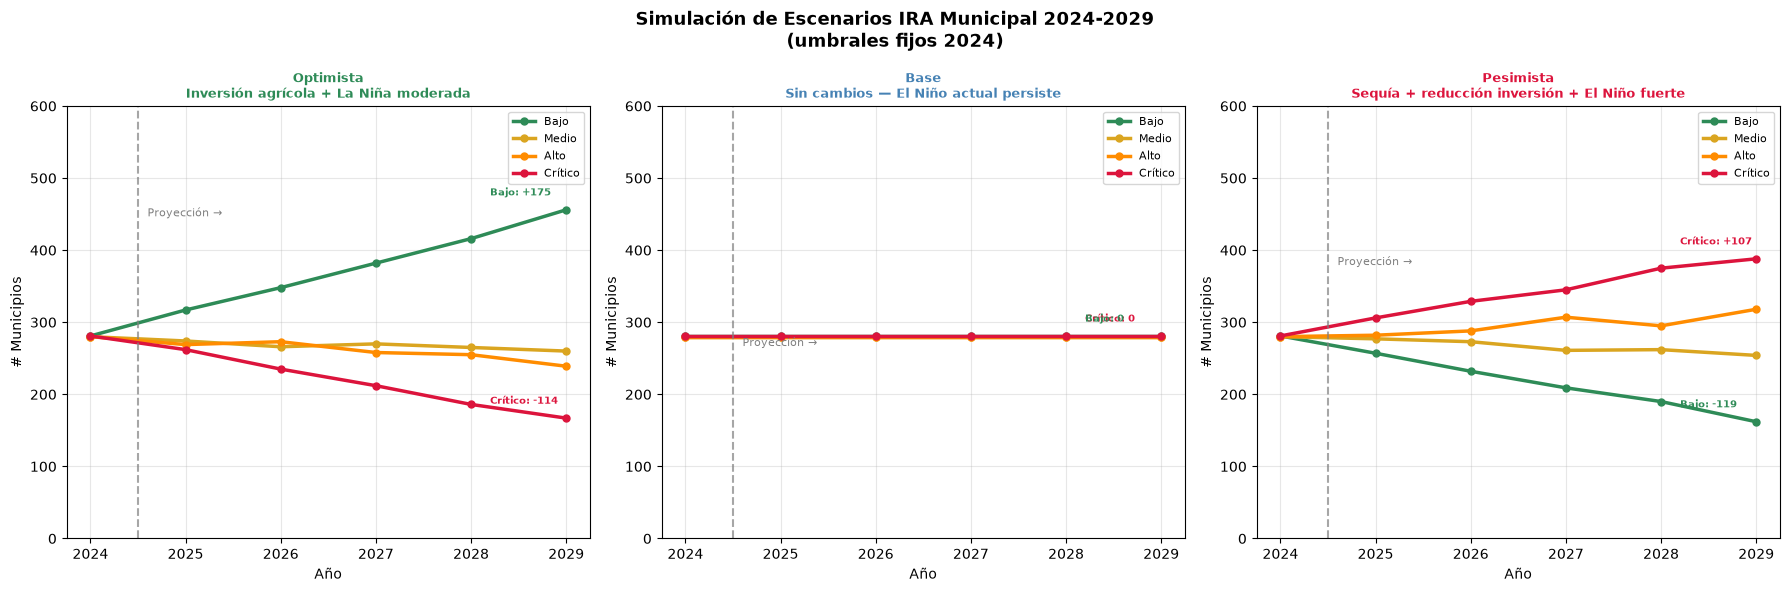

💾 Guardado: reports/figures/simulacion_escenarios_2029.png
💾 Guardados: escenario_optimista/base/pesimista_2029.parquet


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Simulación de Escenarios IRA Municipal 2024-2029\n(umbrales fijos 2024)',
             fontsize=13, fontweight='bold')

colores_nivel = {
    'Bajo':    'seagreen',
    'Medio':   'goldenrod',
    'Alto':    'darkorange',
    'Crítico': 'crimson',
}

for ax, (nombre, params) in zip(axes, ESCENARIOS_V2.items()):
    df_res = resultados_v2.get(nombre)
    if df_res is None:
        # fallback: compute on the fly if missing
        df_res, _, _ = simular_escenario_v2(
            df_base_2024, params, ANOS_PROYECCION,
            umbral_bajo, umbral_medio, umbral_alto
        )

    for nivel, color in colores_nivel.items():
        ax.plot(df_res['anio'], df_res[nivel],
                color=color, linewidth=2.5,
                marker='o', markersize=5,
                label=nivel)

    # Línea vertical separando real de proyección
    ax.axvline(2024.5, color='gray', linestyle='--', alpha=0.7)
    ax.text(2024.6, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1] > 0 else 350,
            'Proyección →', fontsize=8, color='gray')

    ax.set_title(f'{nombre}\n{params["descripcion"]}',
                 fontsize=9, fontweight='bold', color=params['color'])
    ax.set_xlabel('Año')
    ax.set_ylabel('# Municipios')
    ax.set_xticks(df_res['anio'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 600)

    # Anotar 2029
    for nivel in ['Crítico','Bajo']:
        val_2029 = df_res[df_res['anio']==2029][nivel].values[0]
        val_2024 = df_res[df_res['anio']==2024][nivel].values[0]
        cambio = val_2029 - val_2024
        signo = '+' if cambio > 0 else ''
        ax.annotate(f'{nivel}: {signo}{cambio}',
                    xy=(2029, val_2029),
                    xytext=(2028.2, val_2029 + 20),
                    fontsize=7,
                    color=colores_nivel[nivel],
                    fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/simulacion_escenarios_2029.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/simulacion_escenarios_2029.png')

# Guardar resultados
for nombre, df_res in resultados_v2.items():
    nombre_archivo = nombre.lower().replace(' ','_')
    pq.write_table(
        pa.Table.from_pandas(df_res),
        OUTPUT / f'escenario_{nombre_archivo}_2029.parquet',
        compression='snappy'
    )
print('💾 Guardados: escenario_optimista/base/pesimista_2029.parquet')

In [28]:
print('='*60)
print('Exportando estados municipales por año y escenario')
print('='*60)

def simular_escenario_completo(df_base, params, anos, 
                                umbral_bajo, umbral_medio, umbral_alto):
    """
    Igual que simular_escenario_v2 pero guarda estado completo
    de cada municipio por año.
    """
    dfs_por_anio = []
    ira_actual = df_base['ira_riesgo'].copy()
    
    # Estado base 2024
    df_2024 = df_base[['divipola','municipio']].copy()
    df_2024['anio']       = 2024
    df_2024['ira_riesgo'] = ira_actual.values
    df_2024['nivel_ira']  = ira_actual.apply(clasificar_fijo_escenario)
    df_2024['escenario']  = 'Real'
    dfs_por_anio.append(df_2024)

    for anio in anos:
        delta_total = (
            IMPACTO['rendimiento'] * params['delta_rendimiento'] +
            IMPACTO['credito']     * params['delta_credito'] +
            IMPACTO['riego']       * params['delta_riego'] +
            IMPACTO['oni']         * params['delta_oni']
        )
        ira_actual = (ira_actual + delta_total).clip(0, 1)

        df_anio = df_base[['divipola','municipio']].copy()
        df_anio['anio']       = anio
        df_anio['ira_riesgo'] = ira_actual.values
        df_anio['nivel_ira']  = ira_actual.apply(clasificar_fijo_escenario)
        df_anio['escenario']  = params.get('nombre', 'Base')
        dfs_por_anio.append(df_anio)

    return pd.concat(dfs_por_anio, ignore_index=True)

# Agregar nombre a cada escenario
ESCENARIOS_V2['Optimista']['nombre']  = 'Optimista'
ESCENARIOS_V2['Base']['nombre']       = 'Base'
ESCENARIOS_V2['Pesimista']['nombre']  = 'Pesimista'

# Generar estados completos
dfs_escenarios = []

for nombre, params in ESCENARIOS_V2.items():
    print(f'  Generando {nombre}...')
    df_completo = simular_escenario_completo(
        df_base_2024, params, ANOS_PROYECCION,
        umbral_bajo, umbral_medio, umbral_alto
    )
    dfs_escenarios.append(df_completo)

df_escenarios_completo = pd.concat(dfs_escenarios, ignore_index=True)

# Agregar también el histórico real 2021-2024
df_hist_export = df_hist[['divipola','municipio','anio',
                            'ira_riesgo','nivel_ira']].copy()
df_hist_export['escenario'] = 'Real'

# Combinar histórico + proyecciones (sin duplicar 2024)
df_proyecciones = df_escenarios_completo[
    df_escenarios_completo['anio'] > 2024
].copy()

df_timeline_completo = pd.concat(
    [df_hist_export, df_proyecciones],
    ignore_index=True
)

print(f'\n✅ Timeline completo:')
print(f'   Registros: {len(df_timeline_completo):,}')
print(f'   Años reales: 2021-2024')
print(f'   Años proyectados: 2025-2029')
print(f'   Escenarios: Real, Optimista, Base, Pesimista')
print(f'\n   Estructura:')
print(df_timeline_completo.groupby(['escenario','anio']).size().to_string())

# Guardar
pq.write_table(
    pa.Table.from_pandas(df_timeline_completo),
    OUTPUT / 'ira_timeline_completo.parquet',
    compression='snappy'
)
print(f'\n💾 Guardado: ira_timeline_completo.parquet')
print(f'   {(OUTPUT / "ira_timeline_completo.parquet").stat().st_size / (1024*1024):.1f} MB')

Exportando estados municipales por año y escenario
  Generando Optimista...
  Generando Base...
  Generando Pesimista...

✅ Timeline completo:
   Registros: 21,318
   Años reales: 2021-2024
   Años proyectados: 2025-2029
   Escenarios: Real, Optimista, Base, Pesimista

   Estructura:
escenario  anio
Base       2025    1122
           2026    1122
           2027    1122
           2028    1122
           2029    1122
Optimista  2025    1122
           2026    1122
           2027    1122
           2028    1122
           2029    1122
Pesimista  2025    1122
           2026    1122
           2027    1122
           2028    1122
           2029    1122
Real       2021    1122
           2022    1122
           2023    1122
           2024    1122

💾 Guardado: ira_timeline_completo.parquet
   0.2 MB


Generando gráficas por año y escenario...


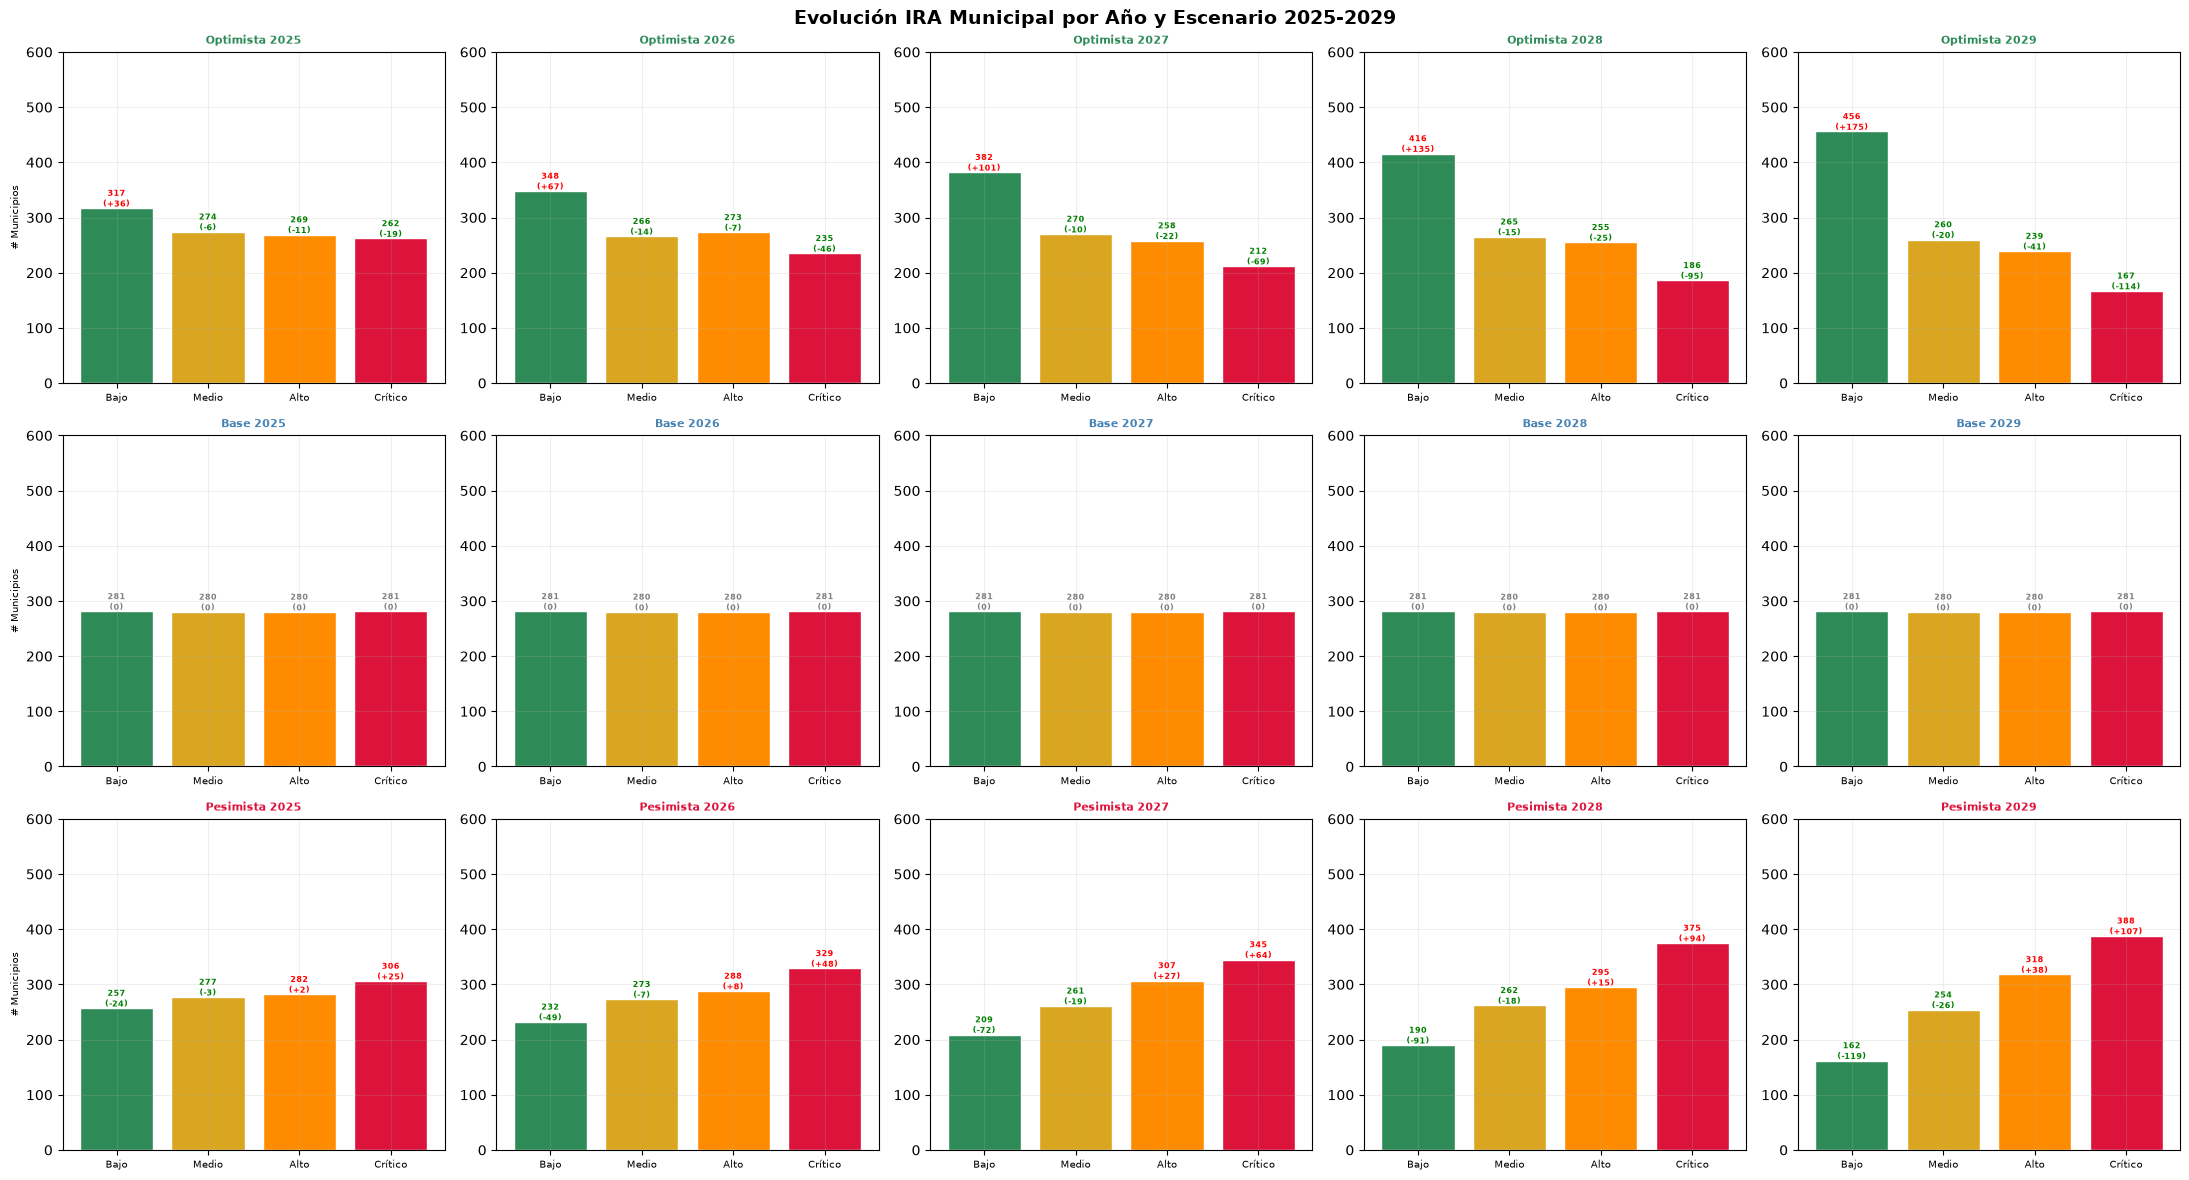

💾 Guardado: reports/figures/ira_por_anio_escenario.png


In [29]:
print('Generando gráficas por año y escenario...')

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('Evolución IRA Municipal por Año y Escenario 2025-2029',
             fontsize=14, fontweight='bold')

escenarios_plot = ['Optimista', 'Base', 'Pesimista']
colores_nivel = {
    'Bajo':    'seagreen',
    'Medio':   'goldenrod', 
    'Alto':    'darkorange',
    'Crítico': 'crimson',
}

for i, escenario in enumerate(escenarios_plot):
    df_esc = df_timeline_completo[
        df_timeline_completo['escenario'] == escenario
    ]
    
    for j, anio in enumerate(ANOS_PROYECCION):
        ax = axes[i][j]
        df_anio = df_esc[df_esc['anio'] == anio]
        
        # Distribución por nivel
        dist = df_anio['nivel_ira'].value_counts()
        niveles = ['Bajo','Medio','Alto','Crítico']
        conteos = [dist.get(n, 0) for n in niveles]
        colores = [colores_nivel[n] for n in niveles]
        
        bars = ax.bar(niveles, conteos, color=colores, edgecolor='white')
        
        # Comparar con 2024
        dist_2024 = df_timeline_completo[
            (df_timeline_completo['escenario']=='Real') &
            (df_timeline_completo['anio']==2024)
        ]['nivel_ira'].value_counts()
        
        for bar, nivel, val in zip(bars, niveles, conteos):
            base = dist_2024.get(nivel, 0)
            cambio = val - base
            signo = '+' if cambio > 0 else ''
            color_text = 'red' if cambio > 0 else 'green' if cambio < 0 else 'gray'
            ax.text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 3,
                   f'{val}\n({signo}{cambio})',
                   ha='center', fontsize=6,
                   color=color_text, fontweight='bold')
        
        ax.set_ylim(0, 600)
        ax.set_title(f'{escenario} {anio}', fontsize=8, fontweight='bold',
                    color=ESCENARIOS_V2[escenario]['color'])
        ax.set_xticklabels(niveles, fontsize=7)
        ax.set_ylabel('# Municipios' if j==0 else '', fontsize=7)
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../reports/figures/ira_por_anio_escenario.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/ira_por_anio_escenario.png')

PARTE F — SHAP Values (Explicabilidad XGBoost)
Calculando SHAP values — modelo clasificación IRA...
Shape shap_values: (1122, 35, 4)
Shape shap_critico: (1122, 35)

Top 15 features por SHAP (clase Crítico):
                       feature  shap_mean
                    rank_sipsa     0.9995
                 rank_frontera     0.8153
              rank_rendimiento     0.8014
                  rank_credito     0.7815
                  rank_aptitud     0.4734
               rank_n_cultivos     0.4274
                  rank_ipm_inv     0.3953
            rank_precipitacion     0.3549
         rank_informalidad_inv     0.3483
rank_priv_inadecuada_eliminaci     0.2482
rank_priv_hacinamiento_crítico     0.2457
                    rank_riego     0.2452
          rank_temperatura_inv     0.2243
 rank_priv_tasa_de_dependencia     0.1514
rank_priv_material_inadecuado_     0.1346


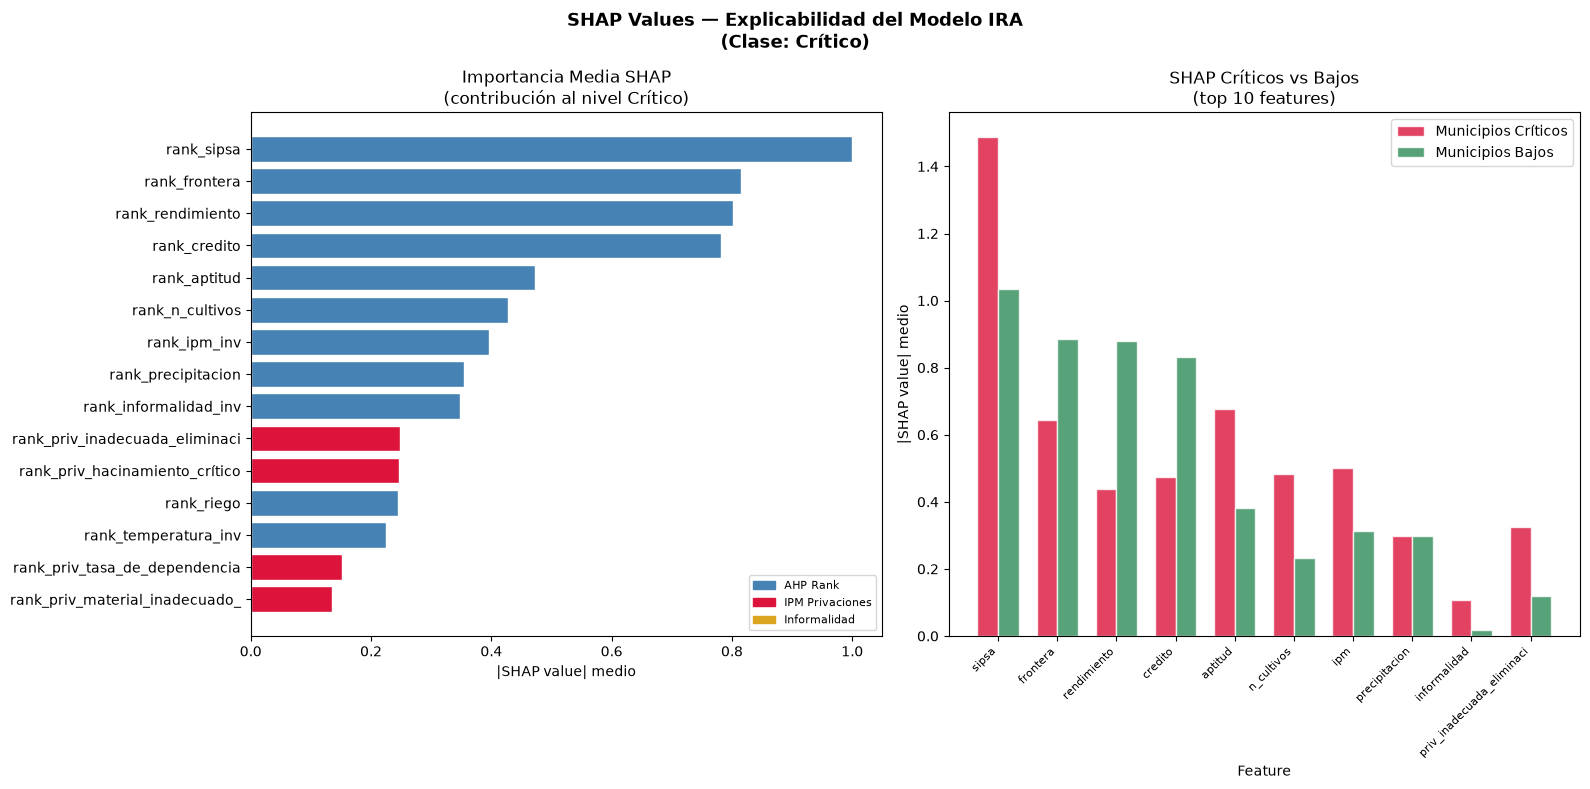

💾 Guardado: reports/figures/shap_values.png


In [30]:
print('='*60)
print('PARTE F — SHAP Values (Explicabilidad XGBoost)')
print('='*60)

import shap

# SHAP para el modelo multiclase (clasificador AHP)
print('Calculando SHAP values — modelo clasificación IRA...')
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X)

# Verificar formato
shap_arr = np.array(shap_values)
print(f'Shape shap_values: {shap_arr.shape}')

if len(shap_arr.shape) == 3:
    # (n_samples, n_features, n_classes)
    shap_critico = shap_arr[:, :, 3]
elif shap_arr.shape == (len(feature_cols), 4):
    # (n_features, n_classes) — promedio ya calculado
    shap_critico = shap_arr[:, 3].reshape(1, -1).repeat(len(X), axis=0)
elif isinstance(shap_values, list):
    # Lista de arrays — shap_values[clase]
    shap_critico = shap_values[3]
else:
    shap_critico = shap_arr

print(f'Shape shap_critico: {shap_critico.shape}')

# Importancia media absoluta por feature
shap_importancia = pd.DataFrame({
    'feature':   feature_cols,
    'shap_mean': np.abs(shap_critico).mean(axis=0)
}).sort_values('shap_mean', ascending=False)

print(f'\nTop 15 features por SHAP (clase Crítico):')
print(shap_importancia.head(15).to_string(index=False))

# Gráficas SHAP
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('SHAP Values — Explicabilidad del Modelo IRA\n(Clase: Crítico)',
             fontsize=13, fontweight='bold')

# Importancia media SHAP
top15_shap = shap_importancia.head(15)
colores_shap = []
for feat in top15_shap['feature']:
    if 'rank_' in feat and 'priv' not in feat:
        colores_shap.append('steelblue')
    elif 'priv' in feat:
        colores_shap.append('crimson')
    elif 'sipsa_p' in feat:
        colores_shap.append('coral')
    else:
        colores_shap.append('goldenrod')

axes[0].barh(top15_shap['feature'][::-1],
             top15_shap['shap_mean'][::-1],
             color=colores_shap[::-1], edgecolor='white')
axes[0].set_title('Importancia Media SHAP\n(contribución al nivel Crítico)')
axes[0].set_xlabel('|SHAP value| medio')

import matplotlib.patches as mpatches
leyenda = [
    mpatches.Patch(color='steelblue', label='AHP Rank'),
    mpatches.Patch(color='crimson',   label='IPM Privaciones'),
    mpatches.Patch(color='goldenrod', label='Informalidad'),
]
axes[0].legend(handles=leyenda, loc='lower right', fontsize=8)

# SHAP Críticos vs Bajos
municipios_criticos = df_ira[df_ira['nivel_ira']=='Crítico']['divipola'].head(5).tolist()
municipios_bajos    = df_ira[df_ira['nivel_ira']=='Bajo']['divipola'].head(5).tolist()

idx_criticos = df_features[df_features['divipola'].isin(municipios_criticos)].index
idx_bajos    = df_features[df_features['divipola'].isin(municipios_bajos)].index

shap_criticos_mean = np.abs(shap_critico[idx_criticos]).mean(axis=0)
shap_bajos_mean    = np.abs(shap_critico[idx_bajos]).mean(axis=0)

top10_feats = shap_importancia.head(10)['feature'].tolist()
idx_feats   = [feature_cols.index(f) for f in top10_feats]

x = np.arange(len(top10_feats))
width = 0.35
axes[1].bar(x - width/2,
            shap_criticos_mean[idx_feats],
            width, label='Municipios Críticos',
            color='crimson', alpha=0.8, edgecolor='white')
axes[1].bar(x + width/2,
            shap_bajos_mean[idx_feats],
            width, label='Municipios Bajos',
            color='seagreen', alpha=0.8, edgecolor='white')
axes[1].set_title('SHAP Críticos vs Bajos\n(top 10 features)')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('|SHAP value| medio')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f.replace('rank_','').replace('_inv','')
                          for f in top10_feats],
                         rotation=45, ha='right', fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/shap_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/shap_values.png')

PARTE G — Cultivos en Riesgo Alimentario
Top 20 cultivos con mayor % producción en municipios Alto/Crítico:
                                         produccion_nacional_ton  produccion_riesgo_ton  pct_en_riesgo
cultivo                                                                                               
Arbol de pan o pepa del pan                            2648.5000              2648.5000       100.0000
Noni                                                      4.0000                 4.0000       100.0000
Orégano                                                   0.5000                 0.5000       100.0000
Otras raíces y tubérculos                                54.0000                54.0000       100.0000
Otros cultivos tropicales tradicionales                3208.3200              3208.3200       100.0000
Pomarrosa                                                 3.0000                 3.0000       100.0000
Toronja                                                 534.0000    

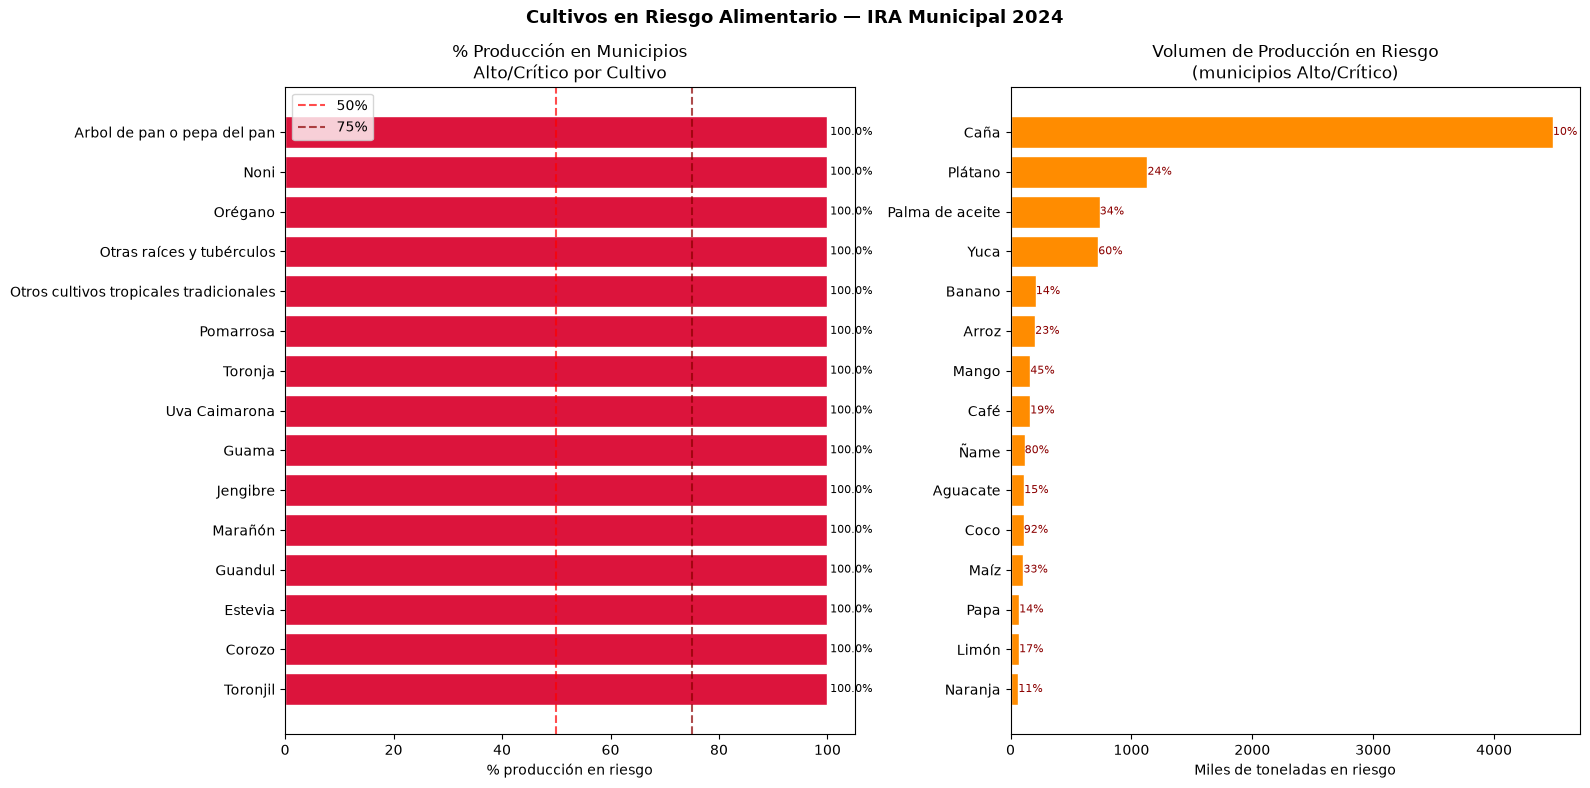

💾 Guardado: reports/figures/cultivos_en_riesgo.png
💾 Guardado: cultivos_en_riesgo.parquet


In [31]:
print('='*60)
print('PARTE G — Cultivos en Riesgo Alimentario')
print('='*60)

df_eva_2024 = df_eva[df_eva['anio'] == 2024].copy()

# Municipios por nivel IRA
mpio_por_nivel = df_ira[['divipola','nivel_ira']].copy()

# Cruzar EVA con IRA
df_cultivos_ira = df_eva_2024.merge(mpio_por_nivel, on='divipola', how='left')
df_cultivos_ira['nivel_ira'] = df_cultivos_ira['nivel_ira'].fillna('Sin datos')

# Producción nacional total por cultivo
prod_nacional = df_cultivos_ira.groupby('cultivo')['produccion_ton'].sum()

# Producción en municipios Alto + Crítico por cultivo
prod_riesgo = df_cultivos_ira[
    df_cultivos_ira['nivel_ira'].isin(['Alto','Crítico'])
].groupby('cultivo')['produccion_ton'].sum()

# % producción en riesgo
df_riesgo_cultivos = pd.DataFrame({
    'produccion_nacional_ton': prod_nacional,
    'produccion_riesgo_ton':   prod_riesgo,
}).fillna(0)
df_riesgo_cultivos['pct_en_riesgo'] = (
    df_riesgo_cultivos['produccion_riesgo_ton'] /
    df_riesgo_cultivos['produccion_nacional_ton'] * 100
).round(1)
df_riesgo_cultivos = df_riesgo_cultivos[
    df_riesgo_cultivos['produccion_nacional_ton'] > 0
].sort_values('pct_en_riesgo', ascending=False)

print(f'Top 20 cultivos con mayor % producción en municipios Alto/Crítico:')
print(df_riesgo_cultivos.head(20).to_string())

# Producción total en riesgo
total_nacional = df_cultivos_ira['produccion_ton'].sum()
total_riesgo   = df_cultivos_ira[
    df_cultivos_ira['nivel_ira'].isin(['Alto','Crítico'])
]['produccion_ton'].sum()
print(f'\nProducción nacional total (2024): {total_nacional/1e6:.2f} millones ton')
print(f'Producción en municipios Alto/Crítico: {total_riesgo/1e6:.2f} millones ton ({total_riesgo/total_nacional*100:.1f}%)')

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Cultivos en Riesgo Alimentario — IRA Municipal 2024',
             fontsize=13, fontweight='bold')

# Top 15 cultivos por % en riesgo
top15_riesgo = df_riesgo_cultivos.head(15)
colores_riesgo = ['crimson' if p >= 75 else 'darkorange' if p >= 50
                  else 'goldenrod' for p in top15_riesgo['pct_en_riesgo']]
axes[0].barh(top15_riesgo.index[::-1],
             top15_riesgo['pct_en_riesgo'][::-1],
             color=colores_riesgo[::-1], edgecolor='white')
axes[0].axvline(50, color='red', linestyle='--', alpha=0.7, label='50%')
axes[0].axvline(75, color='darkred', linestyle='--', alpha=0.7, label='75%')
axes[0].set_title('% Producción en Municipios\nAlto/Crítico por Cultivo')
axes[0].set_xlabel('% producción en riesgo')
axes[0].legend()
for i, (idx, row) in enumerate(top15_riesgo.iloc[::-1].iterrows()):
    axes[0].text(row['pct_en_riesgo'] + 0.5, i,
                 f'{row["pct_en_riesgo"]:.1f}%',
                 va='center', fontsize=8)

# Producción absoluta en riesgo — top 15 por volumen
top15_vol = df_riesgo_cultivos.nlargest(15, 'produccion_riesgo_ton')
axes[1].barh(top15_vol.index[::-1],
             top15_vol['produccion_riesgo_ton'][::-1] / 1e3,
             color='darkorange', edgecolor='white')
axes[1].set_title('Volumen de Producción en Riesgo\n(municipios Alto/Crítico)')
axes[1].set_xlabel('Miles de toneladas en riesgo')
for i, (idx, row) in enumerate(top15_vol.iloc[::-1].iterrows()):
    axes[1].text(row['produccion_riesgo_ton']/1e3 + 0.5, i,
                 f'{row["pct_en_riesgo"]:.0f}%',
                 va='center', fontsize=8, color='darkred')

plt.tight_layout()
plt.savefig('../reports/figures/cultivos_en_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/cultivos_en_riesgo.png')

# Guardar
pq.write_table(
    pa.Table.from_pandas(df_riesgo_cultivos.reset_index()),
    OUTPUT / 'cultivos_en_riesgo.parquet',
    compression='snappy'
)
print('💾 Guardado: cultivos_en_riesgo.parquet')

In [32]:
print('Preparando EVA histórico para el frontend...')

GRUPOS_AGRICOLAS_EVA = [
    'Tubérculos y plátanos',
    'Frutales',
    'Cereales',
    'Hortalizas y verduras',
    'Leguminosas',
    'Oleaginosas y Cacao',
    'Otros cultivos',
]

# Agregar por municipio-año-cultivo
df_eva_front = df_eva.groupby(['divipola','anio','cultivo','grupo_cultivo']).agg(
    produccion_ton     = ('produccion_ton',     'sum'),
    rendimiento_ton_ha = ('rendimiento_ton_ha', 'mean'),
    area_sembrada_ha   = ('area_sembrada_ha',   'sum'),
).reset_index()

# Top 5 cultivos por municipio en 2024
top_cultivos_mpio = df_eva[df_eva['anio']==2024].groupby(
    ['divipola','cultivo']
)['produccion_ton'].sum().reset_index()

top_cultivos_mpio = top_cultivos_mpio.sort_values(
    ['divipola','produccion_ton'], ascending=[True, False]
)
top_cultivos_mpio['rank_cultivo'] = top_cultivos_mpio.groupby('divipola').cumcount() + 1
top5_cultivos = top_cultivos_mpio[top_cultivos_mpio['rank_cultivo'] <= 5]

# Agregar top cultivos al IRA final
df_top5_pivot = top5_cultivos.pivot_table(
    index='divipola',
    columns='rank_cultivo',
    values='cultivo',
    aggfunc='first'
).reset_index()
df_top5_pivot.columns = ['divipola'] + [f'cultivo_top{i}' for i in range(1,6)]

# Agregar al ira_municipal_final
df_ira_con_cultivos = pd.read_parquet(OUTPUT / 'ira_municipal_final.parquet')
df_ira_con_cultivos = df_ira_con_cultivos.merge(df_top5_pivot, on='divipola', how='left')

pq.write_table(
    pa.Table.from_pandas(df_ira_con_cultivos),
    OUTPUT / 'ira_municipal_final.parquet',
    compression='snappy'
)

pq.write_table(
    pa.Table.from_pandas(df_eva_front),
    OUTPUT / 'eva_historico_municipios.parquet',
    compression='snappy'
)

print(f'✅ ira_municipal_final.parquet actualizado con top 5 cultivos')
print(f'✅ eva_historico_municipios.parquet guardado')
print(f'   {len(df_eva_front):,} registros')
print(f'\nEjemplo — Top 5 cultivos Uribia:')
print(df_top5_pivot[df_top5_pivot['divipola']=='44847'].to_string())
print(f'\nEjemplo — Top 5 cultivos Pereira:')
print(df_top5_pivot[df_top5_pivot['divipola']=='66001'].to_string())

Preparando EVA histórico para el frontend...
✅ ira_municipal_final.parquet actualizado con top 5 cultivos
✅ eva_historico_municipios.parquet guardado
   93,486 registros

Ejemplo — Top 5 cultivos Uribia:
    divipola cultivo_top1 cultivo_top2 cultivo_top3 cultivo_top4 cultivo_top5
651    44847      Ahuyama        Melón         Maíz      Patilla       Frijol

Ejemplo — Top 5 cultivos Pereira:
    divipola cultivo_top1 cultivo_top2 cultivo_top3     cultivo_top4 cultivo_top5
829    66001      Plátano      Naranja         Caña  Cebolla de rama    Mandarina


PARTE H — Sistema de Alertas Automáticas
Criterios de alerta roja (todas deben cumplirse):
  1. IRA nivel Alto o Crítico
  2. Sin riego (área_riego_bruta_ha < 100 ha)
  3. El Niño activo (ONI > 0.5) — actual: 0.54
  4. Bajo flujo logístico (flujo_agricola_kg < 50.000 kg)

🔴 Alerta ROJA:     340 municipios
🟠 Alerta NARANJA:  208 municipios
🟡 Alerta AMARILLA: 39 municipios

Total municipios en alerta: 587

Top 15 municipios ALERTA ROJA:
     divipola              municipio nivel_ira  ira_riesgo  area_riego_bruta_ha  flujo_agricola_kg
653     44847                 URIBIA   Crítico      0.8663               0.0000         21500.0000
651     44560                MANAURE   Crítico      0.8552               0.0000          9400.0000
642     44035                ALBANIA   Crítico      0.8277               0.0000             0.0000
158     13188                 CICUCO   Crítico      0.8005               0.0000             0.0000
648     44378              HATONUEVO   Crítico      0.7977        

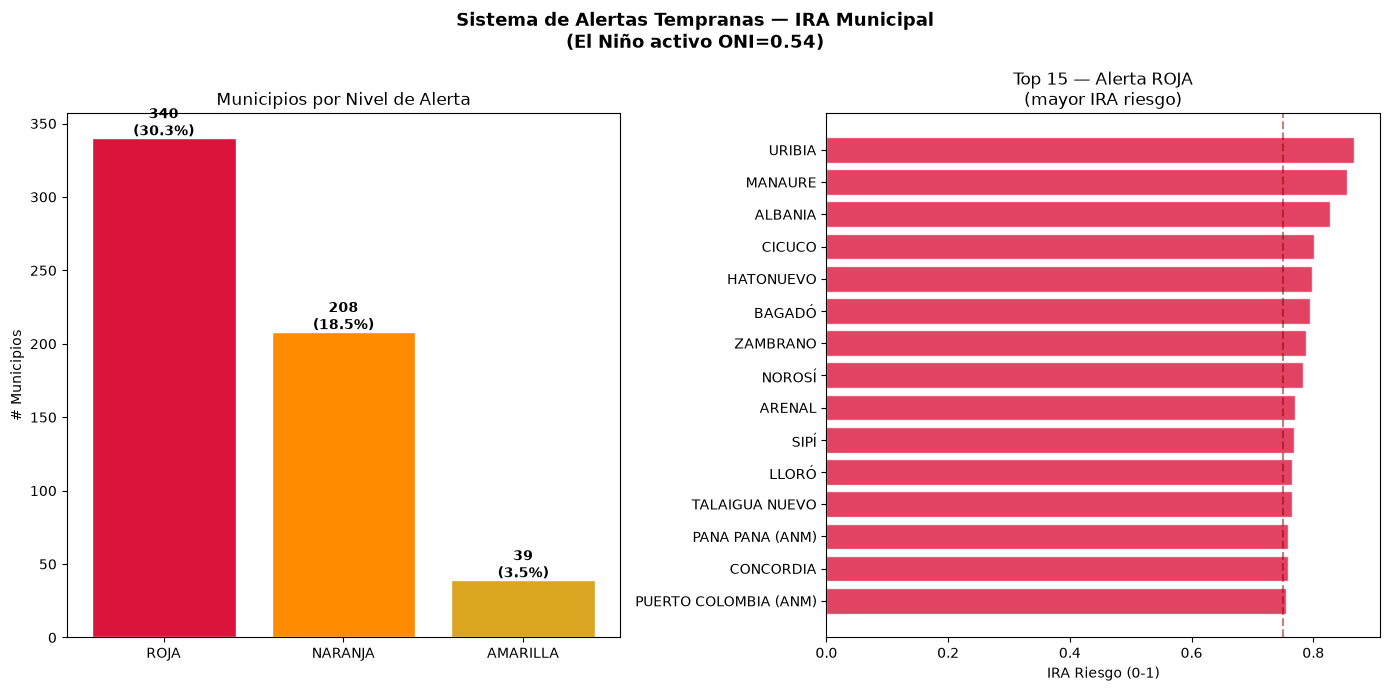


💾 Guardado: alertas_municipios.parquet
💾 Guardado: reports/figures/sistema_alertas.png


In [33]:
print('='*60)
print('PARTE H — Sistema de Alertas Automáticas')
print('='*60)

df_master_full = pd.read_parquet(PRIMARY / 'municipio_features.parquet')
df_ira_full    = pd.read_parquet(OUTPUT / 'ira_municipal_final.parquet')

# Condiciones de alerta simultáneas
print('Criterios de alerta roja (todas deben cumplirse):')
print('  1. IRA nivel Alto o Crítico')
print('  2. Sin riego (área_riego_bruta_ha < 100 ha)')
print('  3. El Niño activo (ONI > 0.5) — actual: 0.54')
print('  4. Bajo flujo logístico (flujo_agricola_kg < 50.000 kg)')
print()

# Mergear datos
df_alertas = df_ira_full[['divipola','municipio','nivel_ira',
                            'ira_riesgo','score_D1','score_D2',
                            'score_D3','score_D4']].copy()
df_alertas = df_alertas.merge(
    df_master_full[['divipola','area_riego_bruta_ha',
                    'flujo_agricola_kg','ipm_rural',
                    'precipitacion_anual_mm']],
    on='divipola', how='left'
)

oni_actual = 0.54  # El Niño activo

# Niveles de alerta
# ROJA — todas las condiciones críticas
alerta_roja = df_alertas[
    (df_alertas['nivel_ira'].isin(['Alto','Crítico'])) &
    (df_alertas['area_riego_bruta_ha'] < 100) &
    (oni_actual > 0.5) &
    (df_alertas['flujo_agricola_kg'] < 50000)
].copy()
alerta_roja['nivel_alerta'] = 'ROJA'

# NARANJA — IRA Alto/Crítico + sin riego O bajo flujo
alerta_naranja = df_alertas[
    (df_alertas['nivel_ira'].isin(['Alto','Crítico'])) &
    ~df_alertas['divipola'].isin(alerta_roja['divipola']) &
    (
        (df_alertas['area_riego_bruta_ha'] < 100) |
        (df_alertas['flujo_agricola_kg'] < 50000)
    )
].copy()
alerta_naranja['nivel_alerta'] = 'NARANJA'

# AMARILLA — IRA Medio con factores de riesgo
alerta_amarilla = df_alertas[
    (df_alertas['nivel_ira'] == 'Medio') &
    (df_alertas['area_riego_bruta_ha'] < 50) &
    (df_alertas['flujo_agricola_kg'] < 20000)
].copy()
alerta_amarilla['nivel_alerta'] = 'AMARILLA'

df_todas_alertas = pd.concat(
    [alerta_roja, alerta_naranja, alerta_amarilla],
    ignore_index=True
)

print(f'🔴 Alerta ROJA:     {len(alerta_roja):,} municipios')
print(f'🟠 Alerta NARANJA:  {len(alerta_naranja):,} municipios')
print(f'🟡 Alerta AMARILLA: {len(alerta_amarilla):,} municipios')
print(f'\nTotal municipios en alerta: {len(df_todas_alertas):,}')

print(f'\nTop 15 municipios ALERTA ROJA:')
print(alerta_roja.nlargest(15,'ira_riesgo')[
    ['divipola','municipio','nivel_ira','ira_riesgo',
     'area_riego_bruta_ha','flujo_agricola_kg']
].to_string())

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Sistema de Alertas Tempranas — IRA Municipal\n(El Niño activo ONI=0.54)',
             fontsize=13, fontweight='bold')

# Conteo por nivel de alerta
niveles_alerta = ['ROJA','NARANJA','AMARILLA']
conteos_alerta = [len(alerta_roja), len(alerta_naranja), len(alerta_amarilla)]
colores_alerta = ['crimson','darkorange','goldenrod']

bars = axes[0].bar(niveles_alerta, conteos_alerta,
                   color=colores_alerta, edgecolor='white')
axes[0].set_title('Municipios por Nivel de Alerta')
axes[0].set_ylabel('# Municipios')
for bar, val in zip(bars, conteos_alerta):
    pct = val / 1122 * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{val}\n({pct:.1f}%)',
                 ha='center', fontweight='bold')

# Top 15 alerta roja por IRA
top15_roja = alerta_roja.nlargest(15,'ira_riesgo')
axes[1].barh(top15_roja['municipio'][::-1],
             top15_roja['ira_riesgo'][::-1],
             color='crimson', edgecolor='white', alpha=0.8)
axes[1].set_title('Top 15 — Alerta ROJA\n(mayor IRA riesgo)')
axes[1].set_xlabel('IRA Riesgo (0-1)')
axes[1].axvline(0.75, color='darkred', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../reports/figures/sistema_alertas.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar
pq.write_table(
    pa.Table.from_pandas(df_todas_alertas),
    OUTPUT / 'alertas_municipios.parquet',
    compression='snappy'
)
print('\n💾 Guardado: alertas_municipios.parquet')
print('💾 Guardado: reports/figures/sistema_alertas.png')

In [34]:
print('Preparando datos consolidados para el mapa...')

# ─── 1. IRA + cultivos + alertas por municipio (año actual) ──────────────────
df_mapa_base = pd.read_parquet(OUTPUT / 'ira_municipal_final.parquet')

# Agregar alertas
df_alertas_mapa = df_todas_alertas[['divipola','nivel_alerta']].copy()
df_mapa_base = df_mapa_base.merge(df_alertas_mapa, on='divipola', how='left')
df_mapa_base['nivel_alerta'] = df_mapa_base['nivel_alerta'].fillna('VERDE')

# ─── 2. Timeline completo con cultivos 2024 para años proyectados ─────────────
df_timeline = pd.read_parquet(OUTPUT / 'ira_timeline_completo.parquet')

# Agregar top 5 cultivos 2024 a todos los años del timeline
df_timeline = df_timeline.merge(
    df_top5_pivot, on='divipola', how='left'
)

# Agregar alertas por año y escenario
def calcular_alertas_anio(df_anio, df_master_full, oni_valor):
    """Calcula alertas para un año específico."""
    df = df_anio.merge(
        df_master_full[['divipola','area_riego_bruta_ha','flujo_agricola_kg']],
        on='divipola', how='left'
    )
    condiciones = pd.Series(['VERDE'] * len(df), index=df.index)

    mask_roja = (
        df['nivel_ira'].isin(['Alto','Crítico']) &
        (df['area_riego_bruta_ha'] < 100) &
        (oni_valor > 0.5) &
        (df['flujo_agricola_kg'] < 50000)
    )
    mask_naranja = (
        df['nivel_ira'].isin(['Alto','Crítico']) &
        ~mask_roja &
        (
            (df['area_riego_bruta_ha'] < 100) |
            (df['flujo_agricola_kg'] < 50000)
        )
    )
    mask_amarilla = (
        (df['nivel_ira'] == 'Medio') &
        (df['area_riego_bruta_ha'] < 50) &
        (df['flujo_agricola_kg'] < 20000)
    )

    condiciones[mask_amarilla] = 'AMARILLA'
    condiciones[mask_naranja]  = 'NARANJA'
    condiciones[mask_roja]     = 'ROJA'

    return condiciones.values

# ONI por año — real para 2021-2024, proyectado para 2025-2029
df_oni_anio = pd.read_parquet(INTERMEDIATE / 'oni_limpia.parquet')
oni_por_anio = {
    2021: df_oni_anio[df_oni_anio['year']==2021]['anom'].mean(),
    2022: df_oni_anio[df_oni_anio['year']==2022]['anom'].mean(),
    2023: df_oni_anio[df_oni_anio['year']==2023]['anom'].mean(),
    2024: df_oni_anio[df_oni_anio['year']==2024]['anom'].mean(),
    2025: 0.54,   # El Niño actual proyectado
    2026: 0.30,   # transición
    2027: -0.10,  # neutro
    2028: -0.30,  # posible La Niña
    2029: -0.10,  # neutro
}

print('Calculando alertas por año y escenario...')
alertas_por_año = []
for (escenario, anio), grupo in df_timeline.groupby(['escenario','anio']):
    oni_val = oni_por_anio.get(anio, 0.54)
    alertas = calcular_alertas_anio(grupo, df_master_full, oni_val)
    grupo_copy = grupo.copy()
    grupo_copy['nivel_alerta'] = alertas
    alertas_por_año.append(grupo_copy)

df_timeline_completo_v2 = pd.concat(alertas_por_año, ignore_index=True)

# ─── 3. Cultivos en riesgo por año ───────────────────────────────────────────
print('Calculando cultivos en riesgo por año...')
dfs_cultivos_anio = []

for anio in [2021, 2022, 2023, 2024]:
    df_eva_anio = df_eva[df_eva['anio'] == anio].copy()
    df_ira_anio = df_hist[df_hist['anio'] == anio][['divipola','nivel_ira']].copy()

    df_cult = df_eva_anio.merge(df_ira_anio, on='divipola', how='left')
    prod_nac  = df_cult.groupby('cultivo')['produccion_ton'].sum()
    prod_riesgo = df_cult[
        df_cult['nivel_ira'].isin(['Alto','Crítico'])
    ].groupby('cultivo')['produccion_ton'].sum()

    df_cr = pd.DataFrame({
        'produccion_nacional_ton': prod_nac,
        'produccion_riesgo_ton':   prod_riesgo,
    }).fillna(0).reset_index()
    df_cr['pct_en_riesgo'] = (
        df_cr['produccion_riesgo_ton'] /
        df_cr['produccion_nacional_ton'] * 100
    ).round(1)
    df_cr['anio'] = anio
    dfs_cultivos_anio.append(df_cr)

# Para años proyectados usar distribución 2024 ajustada por escenario
for anio in [2025, 2026, 2027, 2028, 2029]:
    for escenario in ['Optimista', 'Base', 'Pesimista']:
        df_ira_anio = df_timeline_completo_v2[
            (df_timeline_completo_v2['anio'] == anio) &
            (df_timeline_completo_v2['escenario'] == escenario)
        ][['divipola','nivel_ira']].copy()

        df_cult = df_eva[df_eva['anio']==2024].merge(df_ira_anio, on='divipola', how='left')
        prod_nac = df_cult.groupby('cultivo')['produccion_ton'].sum()
        prod_riesgo = df_cult[
            df_cult['nivel_ira'].isin(['Alto','Crítico'])
        ].groupby('cultivo')['produccion_ton'].sum()

        df_cr = pd.DataFrame({
            'produccion_nacional_ton': prod_nac,
            'produccion_riesgo_ton':   prod_riesgo,
        }).fillna(0).reset_index()
        df_cr['pct_en_riesgo'] = (
            df_cr['produccion_riesgo_ton'] /
            df_cr['produccion_nacional_ton'] * 100
        ).round(1)
        df_cr['anio']      = anio
        df_cr['escenario'] = escenario
        dfs_cultivos_anio.append(df_cr)

df_cultivos_historico = pd.concat(dfs_cultivos_anio, ignore_index=True)

# ─── Guardar todo ─────────────────────────────────────────────────────────────
pq.write_table(
    pa.Table.from_pandas(df_timeline_completo_v2),
    OUTPUT / 'ira_timeline_completo.parquet',
    compression='snappy'
)
pq.write_table(
    pa.Table.from_pandas(df_cultivos_historico),
    OUTPUT / 'cultivos_riesgo_historico.parquet',
    compression='snappy'
)
pq.write_table(
    pa.Table.from_pandas(df_mapa_base),
    OUTPUT / 'ira_municipal_final.parquet',
    compression='snappy'
)

print(f'\n✅ Archivos guardados:')
print(f'   ira_timeline_completo.parquet — {len(df_timeline_completo_v2):,} registros')
print(f'   cultivos_riesgo_historico.parquet — {len(df_cultivos_historico):,} registros')
print(f'   ira_municipal_final.parquet — actualizado con alertas')
print(f'\nEstructura timeline:')
print(df_timeline_completo_v2.groupby(['escenario','anio']).size().to_string())

Preparando datos consolidados para el mapa...
Calculando alertas por año y escenario...
Calculando cultivos en riesgo por año...

✅ Archivos guardados:
   ira_timeline_completo.parquet — 21,318 registros
   cultivos_riesgo_historico.parquet — 3,046 registros
   ira_municipal_final.parquet — actualizado con alertas

Estructura timeline:
escenario  anio
Base       2025    1122
           2026    1122
           2027    1122
           2028    1122
           2029    1122
Optimista  2025    1122
           2026    1122
           2027    1122
           2028    1122
           2029    1122
Pesimista  2025    1122
           2026    1122
           2027    1122
           2028    1122
           2029    1122
Real       2021    1122
           2022    1122
           2023    1122
           2024    1122


In [35]:
print('='*60)
print('Proyección de Cultivos por Año y Escenario 2025-2029')
print('='*60)

# Deltas de rendimiento por escenario (acumulado anual)
DELTA_RENDIMIENTO = {
    'Optimista':  +0.05,   # +5% por año
    'Base':        0.00,   # sin cambio
    'Pesimista':  -0.05,   # -5% por año
}

# Base: producción y rendimiento real 2024
df_eva_2024_base = df_eva[df_eva['anio'] == 2024].copy()
prod_base = df_eva_2024_base.groupby('cultivo').agg(
    produccion_ton_2024     = ('produccion_ton',     'sum'),
    rendimiento_ton_ha_2024 = ('rendimiento_ton_ha', 'mean'),
    area_sembrada_ha_2024   = ('area_sembrada_ha',   'sum'),
    n_municipios_2024       = ('divipola',           'nunique'),
).reset_index()

dfs_proyeccion = []

# Años reales 2021-2024
for anio in [2021, 2022, 2023, 2024]:
    df_eva_anio = df_eva[df_eva['anio'] == anio].copy()
    df_ira_anio = df_hist[df_hist['anio'] == anio][['divipola','nivel_ira']].copy()
    
    df_cult = df_eva_anio.merge(df_ira_anio, on='divipola', how='left')
    
    resumen = df_cult.groupby('cultivo').agg(
        produccion_ton     = ('produccion_ton',     'sum'),
        rendimiento_ton_ha = ('rendimiento_ton_ha', 'mean'),
        area_sembrada_ha   = ('area_sembrada_ha',   'sum'),
        n_municipios       = ('divipola',           'nunique'),
    ).reset_index()
    
    # % en riesgo
    riesgo = df_cult[df_cult['nivel_ira'].isin(['Alto','Crítico'])].groupby(
        'cultivo')['produccion_ton'].sum().reset_index()
    riesgo.columns = ['cultivo','produccion_riesgo_ton']
    
    resumen = resumen.merge(riesgo, on='cultivo', how='left')
    resumen['produccion_riesgo_ton'] = resumen['produccion_riesgo_ton'].fillna(0)
    resumen['pct_en_riesgo'] = (
        resumen['produccion_riesgo_ton'] / resumen['produccion_ton'] * 100
    ).round(1)
    resumen['anio']      = anio
    resumen['escenario'] = 'Real'
    resumen['es_proyeccion'] = False
    dfs_proyeccion.append(resumen)

# Años proyectados 2025-2029
for escenario, delta in DELTA_RENDIMIENTO.items():
    for i, anio in enumerate([2025, 2026, 2027, 2028, 2029], 1):
        
        # IRA proyectado del escenario
        df_ira_anio = df_timeline_completo_v2[
            (df_timeline_completo_v2['anio'] == anio) &
            (df_timeline_completo_v2['escenario'] == escenario)
        ][['divipola','nivel_ira']].copy()
        
        # Cruzar EVA 2024 con IRA proyectado
        df_cult = df_eva_2024_base.merge(df_ira_anio, on='divipola', how='left')
        
        # Aplicar delta de rendimiento acumulado
        factor = (1 + delta) ** i
        df_cult['produccion_ton_proj']     = df_cult['produccion_ton'] * factor
        df_cult['rendimiento_ton_ha_proj'] = df_cult['rendimiento_ton_ha'] * factor
        
        # Agregar por cultivo
        resumen = df_cult.groupby('cultivo').agg(
            produccion_ton     = ('produccion_ton_proj',     'sum'),
            rendimiento_ton_ha = ('rendimiento_ton_ha_proj', 'mean'),
            area_sembrada_ha   = ('area_sembrada_ha',        'sum'),
            n_municipios       = ('divipola',                'nunique'),
        ).reset_index()
        
        # % en riesgo con IRA proyectado
        riesgo = df_cult[
            df_cult['nivel_ira'].isin(['Alto','Crítico'])
        ].groupby('cultivo')['produccion_ton_proj'].sum().reset_index()
        riesgo.columns = ['cultivo','produccion_riesgo_ton']
        
        resumen = resumen.merge(riesgo, on='cultivo', how='left')
        resumen['produccion_riesgo_ton'] = resumen['produccion_riesgo_ton'].fillna(0)
        resumen['pct_en_riesgo'] = (
            resumen['produccion_riesgo_ton'] / resumen['produccion_ton'] * 100
        ).round(1)
        resumen['anio']           = anio
        resumen['escenario']      = escenario
        resumen['es_proyeccion']  = True
        resumen['factor_aplicado'] = round(factor, 4)
        dfs_proyeccion.append(resumen)

df_cultivos_proyeccion = pd.concat(dfs_proyeccion, ignore_index=True)

print(f'✅ Proyección de cultivos calculada:')
print(f'   Registros: {len(df_cultivos_proyeccion):,}')
print(f'   Cultivos: {df_cultivos_proyeccion["cultivo"].nunique():,}')
print(f'   Años: 2021-2029')
print(f'   Escenarios: Real, Optimista, Base, Pesimista')

# Verificar cultivos clave
CULTIVOS_CLAVE = ['Yuca','Plátano','Maíz','Papa','Arroz','Café','Frijol']

print(f'\nProyección cultivos clave — % en riesgo por escenario:')
print(f'\n{"Cultivo":<15} {"2024":>8} {"2025-B":>8} {"2027-B":>8} {"2029-O":>8} {"2029-P":>8}')
print('-'*55)

for cultivo in CULTIVOS_CLAVE:
    df_c = df_cultivos_proyeccion[df_cultivos_proyeccion['cultivo']==cultivo]
    
    p2024 = df_c[(df_c['anio']==2024) & (df_c['escenario']=='Real')]['pct_en_riesgo'].values
    p2025b = df_c[(df_c['anio']==2025) & (df_c['escenario']=='Base')]['pct_en_riesgo'].values
    p2027b = df_c[(df_c['anio']==2027) & (df_c['escenario']=='Base')]['pct_en_riesgo'].values
    p2029o = df_c[(df_c['anio']==2029) & (df_c['escenario']=='Optimista')]['pct_en_riesgo'].values
    p2029p = df_c[(df_c['anio']==2029) & (df_c['escenario']=='Pesimista')]['pct_en_riesgo'].values

    def v(arr): return f'{arr[0]:.1f}%' if len(arr) > 0 else 'N/A'
    print(f'{cultivo:<15} {v(p2024):>8} {v(p2025b):>8} {v(p2027b):>8} {v(p2029o):>8} {v(p2029p):>8}')

# Guardar
pq.write_table(
    pa.Table.from_pandas(df_cultivos_proyeccion),
    OUTPUT / 'cultivos_proyeccion_2029.parquet',
    compression='snappy'
)
print(f'\n💾 Guardado: cultivos_proyeccion_2029.parquet')

Proyección de Cultivos por Año y Escenario 2025-2029
✅ Proyección de cultivos calculada:
   Registros: 3,046
   Cultivos: 163
   Años: 2021-2029
   Escenarios: Real, Optimista, Base, Pesimista

Proyección cultivos clave — % en riesgo por escenario:

Cultivo             2024   2025-B   2027-B   2029-O   2029-P
-------------------------------------------------------
Yuca               65.6%    65.6%    65.6%    47.4%    71.1%
Plátano            25.2%    25.2%    25.2%    15.5%    35.6%
Maíz               36.4%    36.4%    36.4%    27.5%    41.6%
Papa               21.1%    21.1%    21.1%     8.6%    52.5%
Arroz              22.7%    22.7%    22.7%    13.5%    26.4%
Café               16.6%    16.6%    16.6%     6.6%    29.2%
Frijol             30.7%    30.7%    30.7%    15.4%    42.2%

💾 Guardado: cultivos_proyeccion_2029.parquet


PARTE I — Índice de Moran (Autocorrelación Espacial)
Municipios con polígono + IRA: 1,121

Calculando matriz de pesos Queen...
Vecinos promedio: 5.86

Calculando Índice de Moran Global...

Resultados:
  Índice de Moran (I): 0.6251
  Valor esperado E[I]: -0.0009
  p-value:             0.0010
  z-score:             34.9838

✅ AUTOCORRELACIÓN ESPACIAL POSITIVA SIGNIFICATIVA
   Los municipios con IRA similar tienden a estar agrupados
   → El riesgo alimentario tiene estructura territorial clara

Calculando Moran Local (LISA)...

Distribución LISA (p<0.05):
  No significativo: 667 municipios
  LL (Bajo-Bajo): 220 municipios
  HH (Alto-Alto): 207 municipios
  HL (Alto-Bajo): 16 municipios
  LH (Bajo-Alto): 11 municipios

Top 10 clusters HH (Alto-Alto — zonas de alto riesgo agrupado):
    divipola  municipio  ira_riesgo nivel_ira
653    44847     URIBIA      0.8663   Crítico
651    44560    MANAURE      0.8552   Crítico
642    44035    ALBANIA      0.8277   Crítico
158    13188     CICUCO    

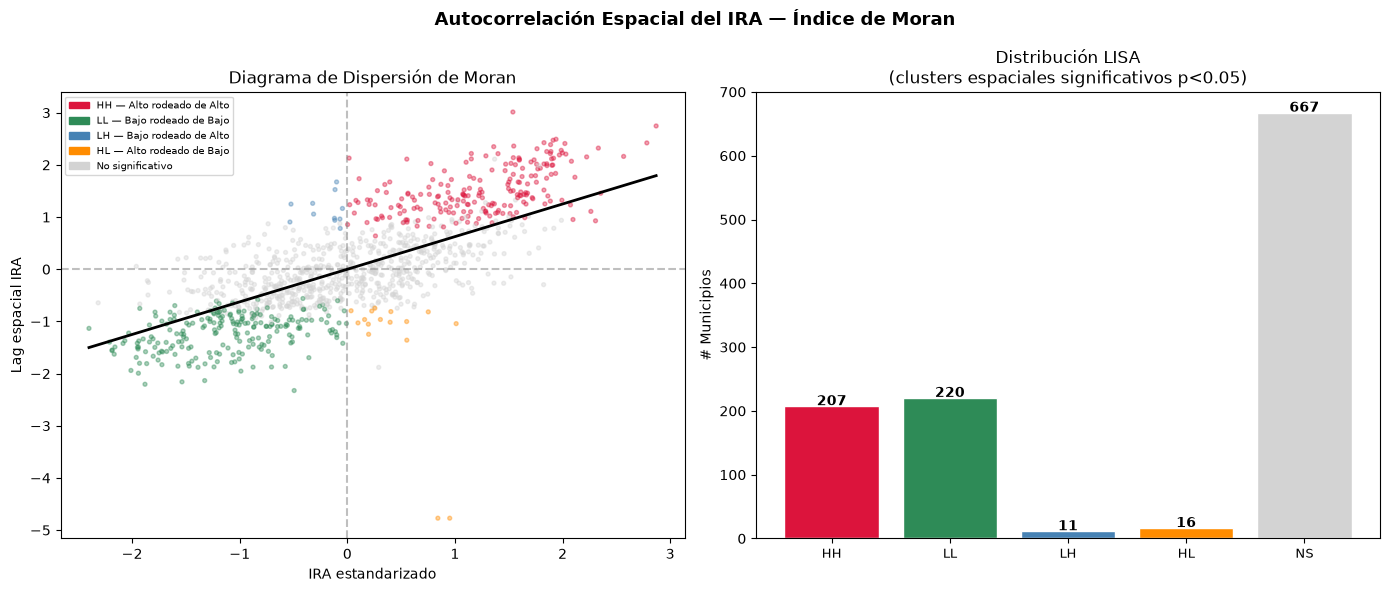

💾 Guardado: reports/figures/moran_espacial.png
💾 Guardado: lisa_clusters.parquet


In [39]:
print('='*60)
print('PARTE I — Índice de Moran (Autocorrelación Espacial)')
print('='*60)

from esda import Moran, Moran_Local
from libpysal import weights
import geopandas as gpd

# Cargar polígonos municipales
gdf_mpio = gpd.read_parquet('../data/02_intermediate/poligonos_municipales.parquet')
gdf_mpio['divipola'] = gdf_mpio['divipola'].astype(str)

# Unir con IRA
df_ira_moran = df_ira[['divipola','ira_riesgo','nivel_ira']].copy()
gdf_ira = gdf_mpio.merge(df_ira_moran, on='divipola', how='inner')
print(f'Municipios con polígono + IRA: {len(gdf_ira):,}')

# Matriz de pesos espaciales Queen
print('\nCalculando matriz de pesos Queen...')
w = weights.Queen.from_dataframe(gdf_ira, silence_warnings=True)
w.transform = 'r'
print(f'Vecinos promedio: {w.mean_neighbors:.2f}')

# Índice de Moran Global
print('\nCalculando Índice de Moran Global...')
moran = Moran(gdf_ira['ira_riesgo'], w, permutations=999)

print(f'\nResultados:')
print(f'  Índice de Moran (I): {moran.I:.4f}')
print(f'  Valor esperado E[I]: {moran.EI:.4f}')
print(f'  p-value:             {moran.p_sim:.4f}')
print(f'  z-score:             {moran.z_sim:.4f}')

if moran.p_sim < 0.05:
    if moran.I > 0:
        print(f'\n✅ AUTOCORRELACIÓN ESPACIAL POSITIVA SIGNIFICATIVA')
        print(f'   Los municipios con IRA similar tienden a estar agrupados')
        print(f'   → El riesgo alimentario tiene estructura territorial clara')
else:
    print(f'\n⚠️  Sin autocorrelación espacial significativa')

# Moran Local LISA
print('\nCalculando Moran Local (LISA)...')
moran_loc = Moran_Local(gdf_ira['ira_riesgo'], w,
                        permutations=999, seed=42)

gdf_ira['moran_q']   = moran_loc.q
gdf_ira['moran_p']   = moran_loc.p_sim
gdf_ira['moran_sig'] = moran_loc.p_sim < 0.05

labels = {1: 'HH (Alto-Alto)', 2: 'LH (Bajo-Alto)',
          3: 'LL (Bajo-Bajo)', 4: 'HL (Alto-Bajo)'}
gdf_ira['lisa_label'] = gdf_ira['moran_q'].map(labels)
gdf_ira.loc[~gdf_ira['moran_sig'], 'lisa_label'] = 'No significativo'

dist_lisa = gdf_ira['lisa_label'].value_counts()
print(f'\nDistribución LISA (p<0.05):')
for label, count in dist_lisa.items():
    print(f'  {label}: {count:,} municipios')

hh = gdf_ira[gdf_ira['lisa_label']=='HH (Alto-Alto)'].sort_values(
    'ira_riesgo', ascending=False)
print(f'\nTop 10 clusters HH (Alto-Alto — zonas de alto riesgo agrupado):')
print(hh.head(10)[['divipola','municipio','ira_riesgo','nivel_ira']].to_string())

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Autocorrelación Espacial del IRA — Índice de Moran',
             fontsize=13, fontweight='bold')

# Diagrama de dispersión de Moran
ira_std = (gdf_ira['ira_riesgo'] - gdf_ira['ira_riesgo'].mean()) / gdf_ira['ira_riesgo'].std()
lag_ira = weights.lag_spatial(w, gdf_ira['ira_riesgo'].values)
lag_std = (lag_ira - lag_ira.mean()) / lag_ira.std()

colores_cuad = []
for q, sig in zip(gdf_ira['moran_q'], gdf_ira['moran_sig']):
    if not sig:
        colores_cuad.append('lightgray')
    elif q == 1:
        colores_cuad.append('crimson')
    elif q == 2:
        colores_cuad.append('steelblue')
    elif q == 3:
        colores_cuad.append('seagreen')
    else:
        colores_cuad.append('darkorange')

axes[0].scatter(ira_std, lag_std, c=colores_cuad, alpha=0.4, s=8)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)

# Línea de regresión (pendiente = I de Moran)
x_line = np.linspace(ira_std.min(), ira_std.max(), 100)
axes[0].plot(x_line, moran.I * x_line, 'k-', linewidth=2,
             label=f'I = {moran.I:.4f} (p={moran.p_sim:.4f})')
axes[0].set_title('Diagrama de Dispersión de Moran')
axes[0].set_xlabel('IRA estandarizado')
axes[0].set_ylabel('Lag espacial IRA')
axes[0].legend()

import matplotlib.patches as mpatches
leyenda = [
    mpatches.Patch(color='crimson',    label='HH — Alto rodeado de Alto'),
    mpatches.Patch(color='seagreen',   label='LL — Bajo rodeado de Bajo'),
    mpatches.Patch(color='steelblue',  label='LH — Bajo rodeado de Alto'),
    mpatches.Patch(color='darkorange', label='HL — Alto rodeado de Bajo'),
    mpatches.Patch(color='lightgray',  label='No significativo'),
]
axes[0].legend(handles=leyenda, fontsize=7, loc='upper left')

# Distribución LISA
niveles_lisa = ['HH (Alto-Alto)','LL (Bajo-Bajo)',
                'LH (Bajo-Alto)','HL (Alto-Bajo)','No significativo']
conteos_lisa = [dist_lisa.get(n, 0) for n in niveles_lisa]
colores_lisa = ['crimson','seagreen','steelblue','darkorange','lightgray']

bars = axes[1].bar(range(len(niveles_lisa)), conteos_lisa,
                   color=colores_lisa, edgecolor='white')
axes[1].set_title('Distribución LISA\n(clusters espaciales significativos p<0.05)')
axes[1].set_ylabel('# Municipios')
axes[1].set_xticks(range(len(niveles_lisa)))
axes[1].set_xticklabels(['HH','LL','LH','HL','NS'], fontsize=9)
for bar, val in zip(bars, conteos_lisa):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/moran_espacial.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/moran_espacial.png')

# Guardar LISA
pq.write_table(
    pa.Table.from_pandas(
        gdf_ira[['divipola','municipio','ira_riesgo',
                 'nivel_ira','lisa_label','moran_p']].copy()
    ),
    OUTPUT / 'lisa_clusters.parquet',
    compression='snappy'
)
print('💾 Guardado: lisa_clusters.parquet')

PARTE J — Municipios Frontera y Costo de Intervención
Municipios en zona frontera (±3% del umbral):
  Frontera Bajo/Medio:   182 municipios
  Frontera Medio/Alto:   174 municipios
  Frontera Alto/Crítico: 148 municipios
  Total:                 504 municipios

Calculando costo de intervención estimado...

Top 15 municipios Críticos más cerca del umbral Alto
(menor intervención necesaria para bajar de nivel):
    divipola           municipio  ira_riesgo  brecha_umbral  credito_pequeno_cop  credito_adicional_estimado
5      05120             CÁCERES      0.5908         0.0046      2739208847.0000               96905145.0093
21     05854            VALDIVIA      0.5910         0.0048      3548025504.0000              101557125.4876
8      05284            FRONTINO      0.5928         0.0066      6231781749.0000              139717776.7204
127    20310            GONZÁLEZ      0.5930         0.0068      1563085009.0000              144011519.9620
95     15377      LABRANZAGRANDE      0.594

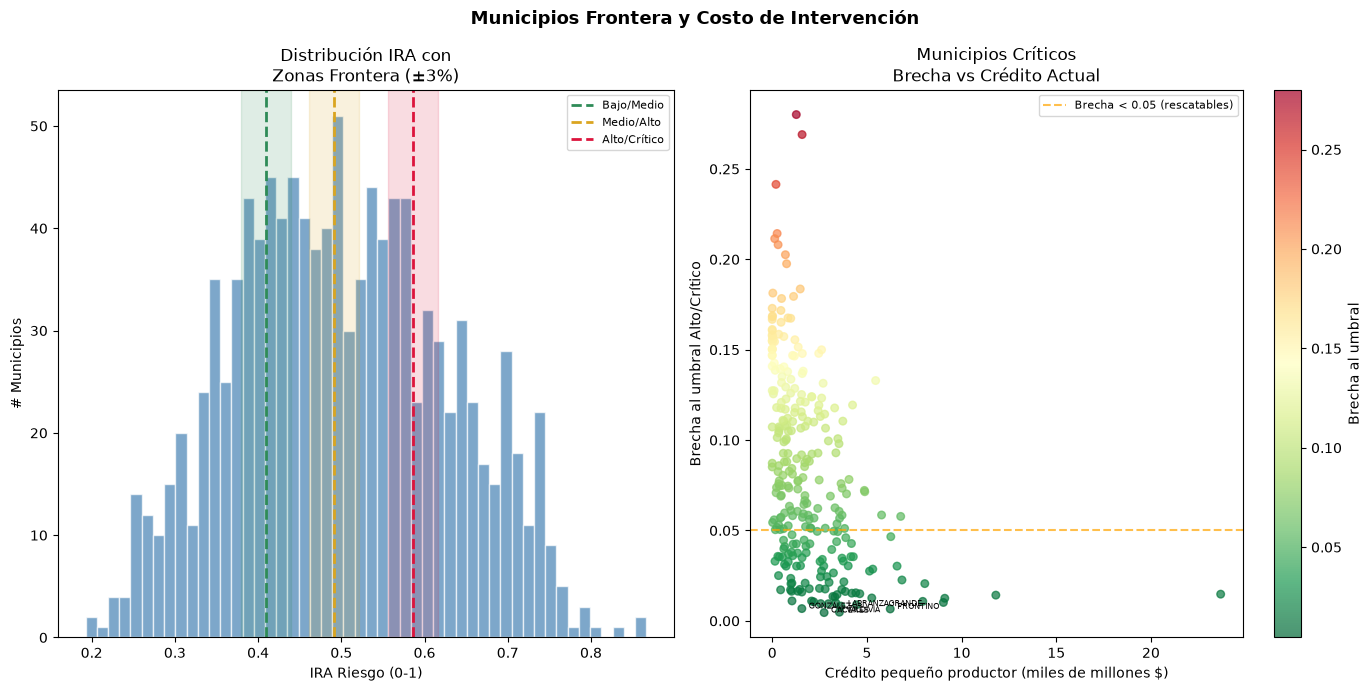

💾 Guardado: reports/figures/municipios_frontera.png
💾 Guardados: municipios_criticos_intervencion.parquet | municipios_frontera.parquet


In [46]:
print('='*60)
print('PARTE J — Municipios Frontera y Costo de Intervención')
print('='*60)

feat_fin = pd.read_parquet(PRIMARY / 'feat_finagro.parquet')
df_master_full = pd.read_parquet(PRIMARY / 'municipio_features.parquet')

# ─── Municipios frontera ──────────────────────────────────────────────────────
margen = 0.03

frontera_bajo_medio = df_ira[
    (df_ira['ira_riesgo'] > umbral_bajo - margen) &
    (df_ira['ira_riesgo'] < umbral_bajo + margen)
].copy()
frontera_bajo_medio['transicion'] = 'Bajo → Medio'

frontera_medio_alto = df_ira[
    (df_ira['ira_riesgo'] > umbral_medio - margen) &
    (df_ira['ira_riesgo'] < umbral_medio + margen)
].copy()
frontera_medio_alto['transicion'] = 'Medio → Alto'

frontera_alto_critico = df_ira[
    (df_ira['ira_riesgo'] > umbral_alto - margen) &
    (df_ira['ira_riesgo'] < umbral_alto + margen)
].copy()
frontera_alto_critico['transicion'] = 'Alto → Crítico'

df_frontera = pd.concat([
    frontera_bajo_medio, frontera_medio_alto, frontera_alto_critico
], ignore_index=True)

print(f'Municipios en zona frontera (±3% del umbral):')
print(f'  Frontera Bajo/Medio:   {len(frontera_bajo_medio):,} municipios')
print(f'  Frontera Medio/Alto:   {len(frontera_medio_alto):,} municipios')
print(f'  Frontera Alto/Crítico: {len(frontera_alto_critico):,} municipios')
print(f'  Total:                 {len(df_frontera):,} municipios')

# ─── Costo de intervención ────────────────────────────────────────────────────
print(f'\nCalculando costo de intervención estimado...')

# Solo columnas necesarias para evitar duplicados
df_criticos = df_ira[df_ira['nivel_ira'] == 'Crítico'][
    ['divipola','municipio','ira_riesgo','nivel_ira',
     'score_D1','score_D2','score_D3','score_D4']
].copy()

df_criticos = df_criticos.merge(
    feat_fin[['divipola','credito_pequeno_cop']],
    on='divipola', how='left'
)
df_criticos = df_criticos.merge(
    df_master_full[['divipola','flujo_agricola_kg',
                    'area_riego_bruta_ha','rendimiento_promedio']],
    on='divipola', how='left'
)

# Brecha al umbral Alto/Crítico
df_criticos['brecha_umbral'] = df_criticos['ira_riesgo'] - umbral_alto

# Estimación crédito adicional necesario
credito_promedio_nacional = feat_fin['credito_pequeno_cop'].median()
factor_credito = 0.015 / 0.10

df_criticos['credito_adicional_estimado'] = (
    df_criticos['brecha_umbral'] / factor_credito *
    credito_promedio_nacional
).clip(lower=0)

df_rescatables = df_criticos.nsmallest(20, 'brecha_umbral')

print(f'\nTop 15 municipios Críticos más cerca del umbral Alto')
print(f'(menor intervención necesaria para bajar de nivel):')
print(df_rescatables.head(15)[
    ['divipola','municipio','ira_riesgo','brecha_umbral',
     'credito_pequeno_cop','credito_adicional_estimado']
].to_string())

print(f'\nEstadísticas brecha (municipios Críticos):')
print(f'  Brecha mínima:   {df_criticos["brecha_umbral"].min():.4f}')
print(f'  Brecha máxima:   {df_criticos["brecha_umbral"].max():.4f}')
print(f'  Brecha promedio: {df_criticos["brecha_umbral"].mean():.4f}')
print(f'\n  Críticos a menos de 0.05 del umbral: {(df_criticos["brecha_umbral"]<0.05).sum():,}')
print(f'  Críticos a menos de 0.10 del umbral: {(df_criticos["brecha_umbral"]<0.10).sum():,}')

# ─── Gráfica ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Municipios Frontera y Costo de Intervención',
             fontsize=13, fontweight='bold')

# Distribución IRA con zonas frontera
axes[0].hist(df_ira['ira_riesgo'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.7)
for umbral_val, color, label in [
    (umbral_bajo,  'seagreen',  'Bajo/Medio'),
    (umbral_medio, 'goldenrod', 'Medio/Alto'),
    (umbral_alto,  'crimson',   'Alto/Crítico'),
]:
    axes[0].axvline(umbral_val, color=color, linestyle='--',
                    linewidth=2, label=label)
    axes[0].axvspan(umbral_val - margen, umbral_val + margen,
                    alpha=0.15, color=color)
axes[0].set_title('Distribución IRA con\nZonas Frontera (±3%)')
axes[0].set_xlabel('IRA Riesgo (0-1)')
axes[0].set_ylabel('# Municipios')
axes[0].legend(fontsize=8)

# Brecha vs crédito actual
sc = axes[1].scatter(
    df_criticos['credito_pequeno_cop'].fillna(0) / 1e9,
    df_criticos['brecha_umbral'],
    c=df_criticos['brecha_umbral'],
    cmap='RdYlGn_r',
    alpha=0.7, s=30
)
plt.colorbar(sc, ax=axes[1], label='Brecha al umbral')
axes[1].set_title('Municipios Críticos\nBrecha vs Crédito Actual')
axes[1].set_xlabel('Crédito pequeño productor (miles de millones $)')
axes[1].set_ylabel('Brecha al umbral Alto/Crítico')
axes[1].axhline(0.05, color='orange', linestyle='--',
                alpha=0.7, label='Brecha < 0.05 (rescatables)')
axes[1].legend(fontsize=8)

for _, row in df_rescatables.head(5).iterrows():
    axes[1].annotate(
        row['municipio'],
        xy=(row['credito_pequeno_cop']/1e9 if pd.notna(row['credito_pequeno_cop']) else 0,
            row['brecha_umbral']),
        fontsize=6, ha='left',
        xytext=(5, 0), textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('../reports/figures/municipios_frontera.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/municipios_frontera.png')

# Guardar
pq.write_table(
    pa.Table.from_pandas(df_criticos),
    OUTPUT / 'municipios_criticos_intervencion.parquet',
    compression='snappy'
)
pq.write_table(
    pa.Table.from_pandas(
        df_frontera[['divipola','municipio','ira_riesgo',
                     'nivel_ira','transicion']]
    ),
    OUTPUT / 'municipios_frontera.parquet',
    compression='snappy'
)
print('💾 Guardados: municipios_criticos_intervencion.parquet | municipios_frontera.parquet')

In [43]:
print(feat_fin.columns.tolist())
print(df_criticos.columns.tolist())

['divipola', 'municipio', 'credito_total_cop', 'n_creditos', 'credito_promedio_cop', 'credito_pequeno_cop', 'pct_credito_pequeno']
['divipola', 'municipio', 'score_D1', 'score_D2', 'score_D3', 'score_D4', 'ira_score', 'ira_riesgo', 'nivel_ira', 'produccion_total_ton', 'area_sembrada_total_ha', 'n_cultivos', 'rendimiento_promedio_x', 'indice_diversificacion', 'area_total_ha', 'score_aptitud_total', 'score_aptitud_promedio', 'area_alta_ha', 'pct_area_alta_aptitud', 'area_condicionada_ha', 'area_no_condicionada_ha', 'area_frontera_total_ha', 'pct_area_no_condicionada', 'n_distritos_riego', 'area_riego_bruta_ha_x', 'n_familias_riego', 'tiene_riego', 'credito_total_cop', 'n_creditos', 'credito_promedio_cop', 'credito_pequeno_cop_x', 'pct_credito_pequeno', 'flujo_agricola_kg_x', 'n_grupos_agricolas', 'n_registros_agricolas', 'flujo_frutas_kg', 'flujo_granos_y_cereales_kg', 'flujo_tuberculos_raices_y_platanos_kg', 'flujo_verduras_y_hortalizas_kg', 'precipitacion_anual_mm', 'distancia_km', 'te